# Detecção de Anomalias com Rede Bayesiana (SIND - Semi-Naive Insider Detector)

Este notebook implementa **arquiteturas de Redes Bayesianas** para detecção de anomalias,
incluindo **nós intermediários (latentes)** e **visualização com interpretabilidade**.

In [ ]:
# Instalação (caso necessário)
!pip install pgmpy scikit-learn networkx matplotlib seaborn xgboost imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 23.0 MB/s eta 0:00:00


In [ ]:
# Instalação da biblioteca imblearn caso não esteja instalada

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, average_precision_score
)
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.cluster import KMeans
from xgboost import XGBClassifier

from pgmpy.models import DiscreteBayesianNetwork # Corrigido para importar DiscreteBayesianNetwork
from pgmpy.estimators import (
    MaximumLikelihoodEstimator,
    BayesianEstimator,
    TreeSearch,
    HillClimbSearch
)
# from pgmpy.estimators.scoring import K2Score, BDeuScore # Comentado para resolver o ModuleNotFoundError
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from imblearn.over_sampling import SMOTEN


import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import entropy
from collections import defaultdict

import time

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregamento e Preparação dos Dados

In [ ]:
# Carregamento dos dados
X_train = pd.read_csv('./X_train.csv')
X_test  = pd.read_csv('./X_test.csv')
y_train = pd.read_csv('./y_train.csv').squeeze()
y_test  = pd.read_csv('./y_test.csv').squeeze()

print(f"Treino: {X_train.shape[0]} amostras, {X_train.shape[1]} features")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição das classes (treino):")
print(y_train.value_counts())
print(f"\nFeatures disponíveis:")
print(X_train.columns.tolist())


Treino: 951 amostras, 48 features
Teste:  300 amostras

Distribuição das classes (treino):
label
0    651
1    300
Name: count, dtype: int64

Features disponíveis:
['logon_total_logons_day', 'logon_total_logoffs_day', 'logon_logon_to_logoff_ratio', 'logon_missing_logoff_count', 'logon_open_sessions_mean', 'logon_open_sessions_max', 'logon_distinct_pcs_used', 'logon_pc_switch_count', 'logon_sessions_total_duration', 'device_unique_pcs_used', 'device_usb_connects', 'device_usb_disconnects', 'device_device_events_total', 'device_unpaired_connections', 'device_unpaired_ratio', 'device_offhour_device_count', 'device_offhour_device_ratio', 'device_mean_daily_device_events', 'device_max_daily_device_events', 'device_std_daily_device_events', 'device_active_days', 'email_n_email', 'email_email_mean_size', 'email_email_mean_text_len', 'email_email_total_attachments', 'email_email_unique_pcs_used', 'email_email_unique_from', 'email_email_unique_to', 'email_email_unique_cc', 'email_email_unique_b

In [ ]:
# Mapeamento de features por domínio comportamental
DOMAIN_MAPPING = {
    'logon': [col for col in X_train.columns if col.startswith('logon_')],
    'device': [col for col in X_train.columns if col.startswith('device_')],
    'email': [col for col in X_train.columns if col.startswith('email_')],
    'file': [col for col in X_train.columns if col.startswith('file_')],
    'http': [col for col in X_train.columns if col.startswith('http_')],
    'web': [col for col in X_train.columns if col.startswith('web_')],
}

# Adicionar if_score como feature especial
if 'if_score' in X_train.columns:
    DOMAIN_MAPPING['anomaly_score'] = ['if_score']

print("Domínios comportamentais identificados:")
for domain, features in DOMAIN_MAPPING.items():
    print(f"  {domain}: {len(features)} features")

Domínios comportamentais identificados:
  logon: 9 features
  device: 12 features
  email: 9 features
  file: 14 features
  http: 3 features
  web: 0 features
  anomaly_score: 1 features


## 2. Seleção de Features e Cálculo de Importância

In [ ]:
# Cálculo de Mutual Information para todas as features
# Remover a coluna 'user' pois ela contém strings e não é uma feature para MI
X_train_numeric = X_train.drop(columns=['user'], errors='ignore')
mi = mutual_info_classif(X_train_numeric, y_train, discrete_features='auto', random_state=42)
mi_scores = pd.Series(mi, index=X_train_numeric.columns).sort_values(ascending=False)

top_features_Mathe = [
    'device_max_daily_device_events',
    'device_mean_daily_device_events',
    'device_active_days',
    'device_offhour_device_count',
    'device_device_events_total',
    'device_usb_connects',
    'device_usb_disconnects',
    'device_offhour_device_ratio',
    'file_unique_file_types',
    'file_total_file_events',
    'file_unique_files',
    'device_std_daily_device_events',
    'logon_total_logoffs_day',
    'http_total_http_events',
    'email_n_email',
    'device_unique_pcs_used',
    'file_pdf_files_accessed',
    'if_score',
    'file_unique_pcs_used',
    'logon_total_logons_day'
]



top_features_damiao = ['device_std_daily_device_events','logon_total_logoffs_day','device_mean_daily_device_events','email_email_total_attachments','email_email_unique_bcc',
               'device_offhour_device_ratio','device_active_days','logon_distinct_pcs_used','logon_sessions_total_duration',
               'logon_missing_logoff_count','file_pdf_files_accessed','file_exe_files_accessed','email_email_unique_to','logon_open_sessions_mean',
               'logon_total_logons_day','email_n_email','logon_logon_to_logoff_ratio','email_email_mean_text_len', 'device_max_daily_device_events', 'device_offhour_device_count',
               'device_device_events_total', 'device_unique_pcs_used','device_usb_connects','http_unique_urls_visited']



teste = ['device_std_daily_device_events','logon_total_logoffs_day','device_mean_daily_device_events','email_email_total_attachments','email_email_unique_bcc',
               'device_offhour_device_ratio','device_active_days','logon_distinct_pcs_used','logon_sessions_total_duration',
               'logon_missing_logoff_count','file_pdf_files_accessed','file_exe_files_accessed','email_email_unique_to','logon_open_sessions_mean',
               'logon_total_logons_day','email_n_email','logon_logon_to_logoff_ratio','email_email_mean_text_len', 'device_max_daily_device_events', 'device_offhour_device_count',
               'device_device_events_total', 'device_unique_pcs_used','device_usb_connects', 'web_web_access_count']


print(len(top_features_Mathe))
print(len(top_features_damiao))
print(len(teste))
######
top_features = top_features_damiao

print("Top-24 features selecionadas (explicitamente definidas):")
print("="*60)
for i, feat in enumerate(top_features, 1):
    # Identificar domínio (reusando mi_scores para o print se disponível)
    domain = next((d for d, fs in DOMAIN_MAPPING.items() if feat in fs), 'other')
    score = mi_scores.get(feat, 0.0) # Pega o score de MI se a feature estiver em mi_scores
    print(f"{i:2d}. [{domain:8s}] {feat:<35} MI={score:.4f}")

20
24
24
Top-24 features selecionadas (explicitamente definidas):
 1. [device  ] device_std_daily_device_events      MI=0.4433
 2. [logon   ] logon_total_logoffs_day             MI=0.4181
 3. [device  ] device_mean_daily_device_events     MI=0.4922
 4. [email   ] email_email_total_attachments       MI=0.1632
 5. [email   ] email_email_unique_bcc              MI=0.0574
 6. [device  ] device_offhour_device_ratio         MI=0.4613
 7. [device  ] device_active_days                  MI=0.4880
 8. [logon   ] logon_distinct_pcs_used             MI=0.0864
 9. [logon   ] logon_sessions_total_duration       MI=0.2434
10. [logon   ] logon_missing_logoff_count          MI=0.1356
11. [file    ] file_pdf_files_accessed             MI=0.3767
12. [file    ] file_exe_files_accessed             MI=0.2428
13. [email   ] email_email_unique_to               MI=0.2898
14. [logon   ] logon_open_sessions_mean            MI=0.2303
15. [logon   ] logon_total_logons_day              MI=0.3454
16. [email   ] emai

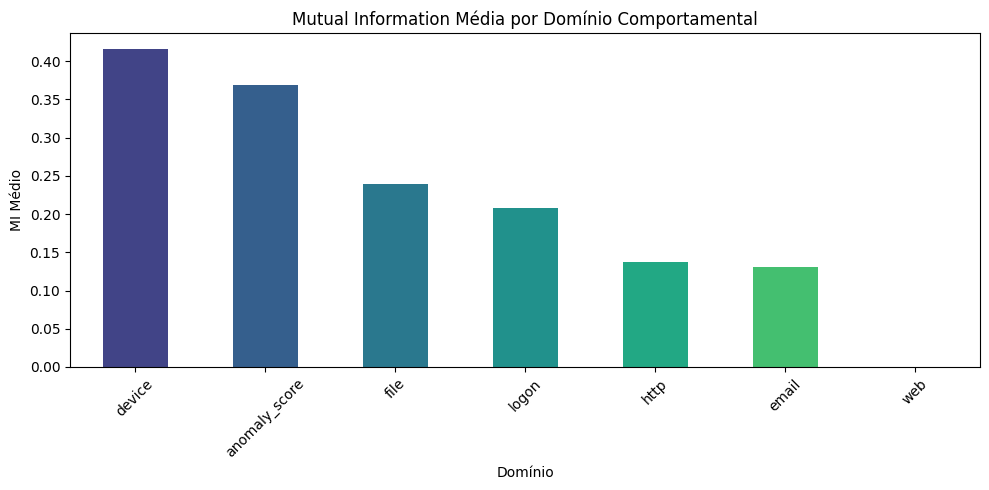


Ranking de domínios por importância:
device           0.416376
anomaly_score    0.368308
file             0.239694
logon            0.208394
http             0.137249
email            0.130792
web              0.000000
dtype: float64


In [ ]:
# Análise de MI por domínio
mi_by_domain = {}
for domain, features in DOMAIN_MAPPING.items():
    domain_mi = mi_scores[features].mean() if features else 0
    mi_by_domain[domain] = domain_mi

mi_domain_df = pd.Series(mi_by_domain).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(mi_domain_df)))
mi_domain_df.plot(kind='bar', color=colors)
plt.title('Mutual Information Média por Domínio Comportamental')
plt.ylabel('MI Médio')
plt.xlabel('Domínio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nRanking de domínios por importância:")
print(mi_domain_df)

## 3. Discretização de Features

In [ ]:
def discretize_data(X_train, X_test, n_bins=5, strategy='quantile'):
    """
    Discretiza os dados usando KBinsDiscretizer.
    """
    discretizer = KBinsDiscretizer(
        n_bins=n_bins,
        encode='ordinal',
        strategy=strategy,
        subsample=None
    )

    X_train_disc = pd.DataFrame(
        discretizer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    ).astype(int)

    X_test_disc = pd.DataFrame(
        discretizer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    ).astype(int)

    return X_train_disc, X_test_disc, discretizer

# Discretização
N_BINS = 5
STRATEGY = 'quantile'

X_train_sel = X_train[top_features].copy()
X_test_sel = X_test[top_features].copy()

X_train_disc, X_test_disc, discretizer = discretize_data(
    X_train_sel, X_test_sel,
    n_bins=N_BINS,
    strategy=STRATEGY
)

print(f"Discretização: {STRATEGY} com {N_BINS} bins")
print(f"Shape: {X_train_disc.shape}")

Discretização: quantile com 5 bins
Shape: (951, 24)


## 4. Criação de Features Intermediárias (Nós Latentes)

Vamos criar **nós latentes** que representam o "estado comportamental" agregado de cada domínio.
Isso permite:
- Reduzir a complexidade da rede
- Capturar padrões hierárquicos
- Melhorar a interpretabilidade

In [ ]:
def create_latent_features(X_disc, domain_mapping, top_features, n_latent_states=3):
    """
    Cria features latentes agregando features de cada domínio usando clustering.

    Parameters:
    -----------
    X_disc : DataFrame - dados discretizados
    domain_mapping : dict - mapeamento domínio -> features
    top_features : list - features selecionadas
    n_latent_states : int - número de estados para cada nó latente

    Returns:
    --------
    X_with_latent : DataFrame com features latentes adicionadas
    latent_names : lista de nomes das features latentes
    feature_to_latent : mapeamento feature -> latente
    """
    X_latent = X_disc.copy()
    latent_names = []
    feature_to_latent = {}
    kmeans_models = {}

    for domain, all_domain_features in domain_mapping.items():
        # Filtrar apenas features que estão no top_features
        domain_features = [f for f in all_domain_features if f in top_features]

        if len(domain_features) >= 2:  # Só cria latente se tiver 2+ features
            latent_name = f'latent_{domain}'

            # Usar KMeans para criar estados latentes
            domain_data = X_disc[domain_features].values
            kmeans = KMeans(n_clusters=n_latent_states, random_state=42, n_init=10)
            X_latent[latent_name] = kmeans.fit_predict(domain_data)

            latent_names.append(latent_name)
            kmeans_models[latent_name] = kmeans

            # Mapear features para este latente
            for feat in domain_features:
                feature_to_latent[feat] = latent_name

            print(f"Criado {latent_name}: {len(domain_features)} features -> {n_latent_states} estados")

    return X_latent, latent_names, feature_to_latent, kmeans_models

# Criar features latentes
N_LATENT_STATES = 3

X_train_latent, latent_names, feature_to_latent, kmeans_models = create_latent_features(
    X_train_disc, DOMAIN_MAPPING, top_features, N_LATENT_STATES
)

# Aplicar aos dados de teste
X_test_latent = X_test_disc.copy()
for domain, features in DOMAIN_MAPPING.items():
    domain_features = [f for f in features if f in top_features]
    latent_name = f'latent_{domain}'
    if latent_name in kmeans_models:
        X_test_latent[latent_name] = kmeans_models[latent_name].predict(
            X_test_disc[domain_features].values
        )

print(f"\nFeatures latentes criadas: {latent_names}")

Criado latent_logon: 7 features -> 3 estados
Criado latent_device: 9 features -> 3 estados
Criado latent_email: 5 features -> 3 estados
Criado latent_file: 2 features -> 3 estados

Features latentes criadas: ['latent_logon', 'latent_device', 'latent_email', 'latent_file']


## 5. Definição das Arquiteturas de Rede

Vamos comparar diferentes arquiteturas:

1. **Naive Bayes (Baseline)**: Label → todas as features
2. **Hierárquica**: Label → Latentes → Features
3. **Semi-Naive**: Naive + dependências intra-domínio
4. **TAN (Tree-Augmented)**: Naive + árvore entre features
5. **Híbrida**: Combina hierárquica com dependências

In [ ]:
def create_naive_bayes_edges(features):
    """Arquitetura Naive Bayes: label -> todas as features"""
    return [('label', feat) for feat in features]

def create_hierarchical_edges(features, latent_names, feature_to_latent):
    """
    Arquitetura Hierárquica:
    - label -> latentes
    - latentes -> features do domínio
    - features sem latente -> label diretamente
    """
    edges = []

    # Label -> Latentes
    for latent in latent_names:
        edges.append(('label', latent))

    # Latentes -> Features
    for feat in features:
        if feat in feature_to_latent:
            edges.append((feature_to_latent[feat], feat))
        else:
            # Features sem latente conectam direto ao label
            edges.append(('label', feat))

    return edges

def create_semi_naive_edges(features, feature_to_latent):
    """
    Arquitetura Semi-Naive:
    - label -> todas as features
    - dependências entre features do mesmo domínio (chain)
    """
    edges = [('label', feat) for feat in features]

    # Agrupar features por domínio
    domain_features = defaultdict(list)
    for feat in features:
        if feat in feature_to_latent:
            domain = feature_to_latent[feat].replace('latent_', '')
            domain_features[domain].append(feat)

    # Criar cadeia dentro de cada domínio
    for domain, feats in domain_features.items():
        if len(feats) >= 2:
            for i in range(len(feats) - 1):
                edges.append((feats[i], feats[i+1]))

    return edges

def create_hybrid_edges(features, latent_names, feature_to_latent):
    """
    Arquitetura Híbrida:
    - label -> latentes
    - latentes -> features
    - label -> features (conexão direta também)
    - dependências entre latentes correlacionados
    """
    edges = []

    # Label -> Latentes
    for latent in latent_names:
        edges.append(('label', latent))

    # Latentes -> Features + Label -> Features
    for feat in features:
        edges.append(('label', feat))  # Conexão direta
        if feat in feature_to_latent:
            edges.append((feature_to_latent[feat], feat))

    # Dependência entre latentes (baseado em correlação esperada)
    # device e file geralmente correlacionados
    if 'latent_device' in latent_names and 'latent_file' in latent_names:
        edges.append(('latent_device', 'latent_file'))

    return edges

print("Arquiteturas definidas:")
print("1. Naive Bayes (baseline)")
print("2. Hierárquica (com nós latentes)")
print("3. Semi-Naive (dependências intra-domínio)")
print("4. Híbrida (combinação)")

Arquiteturas definidas:
1. Naive Bayes (baseline)
2. Hierárquica (com nós latentes)
3. Semi-Naive (dependências intra-domínio)
4. Híbrida (combinação)


## 6. Treinamento e Avaliação das Arquiteturas

In [ ]:
def train_and_evaluate_bn(train_df, test_df, edges, estimator_type='MLE',
                          prior_type='BDeu', equivalent_sample_size=5):
    """
    Treina uma Rede Bayesiana e avalia no conjunto de teste.
    """
    # Criar modelo
    model = DiscreteBayesianNetwork(edges) # Alterado de BayesianNetwork para DiscreteBayesianNetwork

    # Treinamento
    start_time = time.time()

    if estimator_type == 'MLE':
        model.fit(train_df, estimator=MaximumLikelihoodEstimator)
    else:
        model.fit(
            train_df,
            estimator=BayesianEstimator,
            prior_type=prior_type,
            equivalent_sample_size=equivalent_sample_size
        )

    train_time = time.time() - start_time

    # Inferência
    inference = VariableElimination(model)

    start_time = time.time()
    y_pred = []
    y_prob = []

    X_test_only = test_df.drop('label', axis=1)

    for _, row in X_test_only.iterrows():
        evidence = row.to_dict()
        try:
            q = inference.map_query(['label'], evidence=evidence, show_progress=False)
            y_pred.append(q['label'])

            prob = inference.query(['label'], evidence=evidence, show_progress=False)
            prob_value = prob.values[1] if len(prob.values) > 1 else 0.5
            if np.isnan(prob_value):
                prob_value = 0.5 # Default to 0.5 if probability is NaN
            y_prob.append(prob_value)
        except:
            y_pred.append(0)
            y_prob.append(0.5)

    inference_time = time.time() - start_time

    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    y_true = test_df['label'].values

    # Métricas
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'AUPRC': average_precision_score(y_true, y_prob),
        'Train Time (s)': train_time,
        'Inference Time (s)': inference_time
    }

    return model, y_pred, y_prob, metrics

In [ ]:
def evaluate_sklearn_nb(model, X_train, X_test, y_train, y_test, model_name):
    """
    Treina e avalia um modelo Naive Bayes do sklearn.
    """
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    inference_time = time.time() - start_time

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'AUPRC': average_precision_score(y_test, y_prob),
        'Train Time (s)': train_time,
        'Inference Time (s)': inference_time
    }

    return y_pred, y_prob, metrics

In [ ]:
# Preparar dados para cada arquitetura
print("="*70)
print("COMPARAÇÃO DE ARQUITETURAS")
print("="*70)

results = {}
models = {}

# 1. NAIVE BAYES (baseline)
print("\n1. Treinando Naive Bayes (baseline)...")
train_df_nb = X_train_disc.copy()
train_df_nb['label'] = y_train.values
test_df_nb = X_test_disc.copy()
test_df_nb['label'] = y_test.values

edges_nb = create_naive_bayes_edges(top_features)
model_nb, y_pred_nb, y_prob_nb, metrics_nb = train_and_evaluate_bn(
    train_df_nb, test_df_nb, edges_nb, 'MLE'
)
results['Naive Bayes'] = metrics_nb
models['Naive Bayes'] = (model_nb, edges_nb)
print(f"   F1: {metrics_nb['F1-Score']:.4f}, AUC: {metrics_nb['ROC-AUC']:.4f}")

# 2. HIERÁRQUICA
print("\n2. Treinando Hierárquica (com latentes)...")
# Usar dados com latentes, mas remover features originais que têm latentes
features_for_hier = [f for f in top_features if f not in feature_to_latent]
features_hier = features_for_hier + latent_names

train_df_hier = X_train_latent[features_hier].copy()
train_df_hier['label'] = y_train.values
test_df_hier = X_test_latent[features_hier].copy()
test_df_hier['label'] = y_test.values

edges_hier = [('label', f) for f in features_hier]
model_hier, y_pred_hier, y_prob_hier, metrics_hier = train_and_evaluate_bn(
    train_df_hier, test_df_hier, edges_hier, 'Bayesian', 'BDeu', 5
)
results['Hierárquica (Latentes)'] = metrics_hier
models['Hierárquica (Latentes)'] = (model_hier, edges_hier)
print(f"   F1: {metrics_hier['F1-Score']:.4f}, AUC: {metrics_hier['ROC-AUC']:.4f}")

# 3. HIERÁRQUICA COMPLETA (latentes + features)
print("\n3. Treinando Hierárquica Completa...")
all_features_hier = top_features + latent_names
train_df_hier2 = X_train_latent[all_features_hier].copy()
train_df_hier2['label'] = y_train.values
test_df_hier2 = X_test_latent[all_features_hier].copy()
test_df_hier2['label'] = y_test.values

edges_hier2 = create_hierarchical_edges(top_features, latent_names, feature_to_latent)
model_hier2, y_pred_hier2, y_prob_hier2, metrics_hier2 = train_and_evaluate_bn(
    train_df_hier2, test_df_hier2, edges_hier2, 'Bayesian', 'BDeu', 5
)
results['Hierárquica Completa'] = metrics_hier2
models['Hierárquica Completa'] = (model_hier2, edges_hier2)
print(f"   F1: {metrics_hier2['F1-Score']:.4f}, AUC: {metrics_hier2['ROC-AUC']:.4f}")

# 4. SEMI-NAIVE
print("\n4. Treinando Semi-Naive (dependências intra-domínio)...")
edges_semi = create_semi_naive_edges(top_features, feature_to_latent)
model_semi, y_pred_semi, y_prob_semi, metrics_semi = train_and_evaluate_bn(
    train_df_nb, test_df_nb, edges_semi, 'Bayesian', 'BDeu', 5
)
results['Semi-Naive'] = metrics_semi
models['Semi-Naive'] = (model_semi, edges_semi)
print(f"   F1: {metrics_semi['F1-Score']:.4f}, AUC: {metrics_semi['ROC-AUC']:.4f}")

# 5. HÍBRIDA
print("\n5. Treinando Híbrida...")
edges_hybrid = create_hybrid_edges(top_features, latent_names, feature_to_latent)
model_hybrid, y_pred_hybrid, y_prob_hybrid, metrics_hybrid = train_and_evaluate_bn(
    train_df_hier2, test_df_hier2, edges_hybrid, 'Bayesian', 'BDeu', 5
)
results['Híbrida'] = metrics_hybrid
models['Híbrida'] = (model_hybrid, edges_hybrid)
print(f"   F1: {metrics_hybrid['F1-Score']:.4f}, AUC: {metrics_hybrid['ROC-AUC']:.4f}")

## 6. XGBClassifier (dados discretizados)
results_sklearn = {}

print("\nTreinando: XGBClassifier (dados discretizados)...")
XGB = XGBClassifier()
_, _, metrics = evaluate_sklearn_nb(
    XGB, X_train_disc, X_test_disc, y_train, y_test, 'XGBClassifier'
)
results_sklearn['XGBClassifier (discreto)'] = metrics
print(f"  → Accuracy: {metrics['Accuracy']:.4f}, F1: {metrics['F1-Score']:.4f}, AUC: {metrics['ROC-AUC']:.4f}")

COMPARAÇÃO DE ARQUITETURAS

1. Treinando Naive Bayes (baseline)...
   F1: 0.6667, AUC: 0.8870

2. Treinando Hierárquica (com latentes)...
   F1: 0.4262, AUC: 0.9058

3. Treinando Hierárquica Completa...
   F1: 0.4262, AUC: 0.9058

4. Treinando Semi-Naive (dependências intra-domínio)...
   F1: 0.8696, AUC: 0.9944

5. Treinando Híbrida...
   F1: 0.8095, AUC: 0.9928

Treinando: XGBClassifier (dados discretizados)...
  → Accuracy: 0.9900, F1: 0.9231, AUC: 0.9997


In [ ]:
# Tabela de resultados
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("\n" + "="*80)
print("RESULTADOS - Comparaç\u00e3o de Arquiteturas")
print("="*80)
print(results_df.to_string())

# Melhor por F1
best_arch = results_df['F1-Score'].idxmax()
print(f"\n🏆 Melhor arquitetura (F1-Score): {best_arch}")


RESULTADOS - Comparação de Arquiteturas
                        Accuracy  Precision  Recall  F1-Score  ROC-AUC   AUPRC  Train Time (s)  Inference Time (s)
Naive Bayes               0.9467     0.5926  0.7619    0.6667   0.8870  0.6177          0.0801              1.6404
Hierárquica (Latentes)    0.8833     0.3250  0.6190    0.4262   0.9058  0.5186          0.0113              0.5206
Hierárquica Completa      0.8833     0.3250  0.6190    0.4262   0.9058  0.5186          0.0594              1.9330
Semi-Naive                0.9800     0.8000  0.9524    0.8696   0.9944  0.9299          0.0698              2.0864
Híbrida                   0.9733     0.8095  0.8095    0.8095   0.9928  0.9393          0.0705              2.3498

🏆 Melhor arquitetura (F1-Score): Semi-Naive


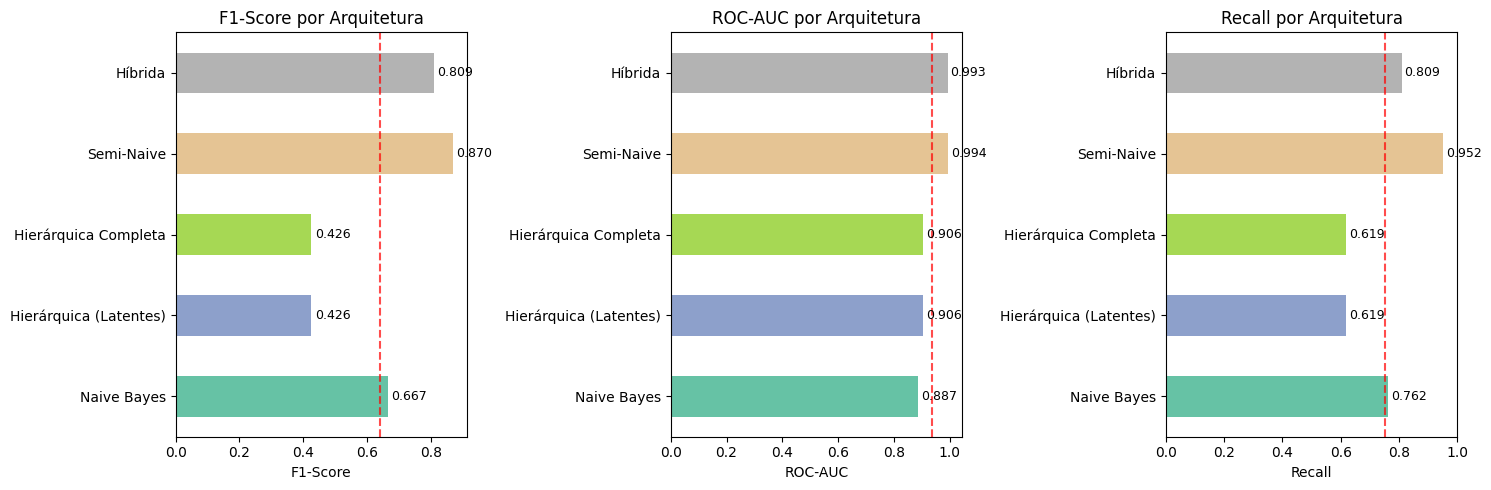

In [ ]:
# Visualização dos resultados
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['F1-Score', 'ROC-AUC', 'Recall']
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

for ax, metric in zip(axes, metrics_to_plot):
    bars = results_df[metric].plot(kind='barh', ax=ax, color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} por Arquitetura')
    ax.axvline(x=results_df[metric].mean(), color='red', linestyle='--', alpha=0.7)

    # Adicionar valores nas barras
    for i, v in enumerate(results_df[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('comparacao_arquiteturas.png', dpi=150, bbox_inches='tight')
plt.show()

#### 6.2. Comparação : BN vs Sklearn

In [ ]:

# Combinar todos os resultados
all_results = {}

# Adicionar resultados BN com prefixo
for name, metrics in results.items():
    all_results[f'BN: {name}'] = metrics

# Adicionar resultados sklearn com prefixo
for name, metrics in results_sklearn.items():
    all_results[f'SK: {name}'] = metrics

# Criar DataFrame consolidado
all_results_df = pd.DataFrame(all_results).T
all_results_df = all_results_df.round(4)

print("="*80)
print("COMPARAÇÃO COMPLETA - Rede Bayesiana (pgmpy) vs Scikit-Learn")
print("="*80)
print(all_results_df.to_string())

COMPARAÇÃO COMPLETA - Rede Bayesiana (pgmpy) vs Scikit-Learn
                              Accuracy  Precision  Recall  F1-Score  ROC-AUC   AUPRC  Train Time (s)  Inference Time (s)
BN: Naive Bayes                 0.9467     0.5926  0.7619    0.6667   0.8870  0.6177          0.0801              1.6404
BN: Hierárquica (Latentes)      0.8833     0.3250  0.6190    0.4262   0.9058  0.5186          0.0113              0.5206
BN: Hierárquica Completa        0.8833     0.3250  0.6190    0.4262   0.9058  0.5186          0.0594              1.9330
BN: Semi-Naive                  0.9800     0.8000  0.9524    0.8696   0.9944  0.9299          0.0698              2.0864
BN: Híbrida                     0.9733     0.8095  0.8095    0.8095   0.9928  0.9393          0.0705              2.3498
SK: XGBClassifier (discreto)    0.9900     1.0000  0.8571    0.9231   0.9997  0.9956          0.0271              0.0058


### 7. Matriz de Confusão do Melhor Modelo

Melhor modelo (F1-Score): Semi-Naive


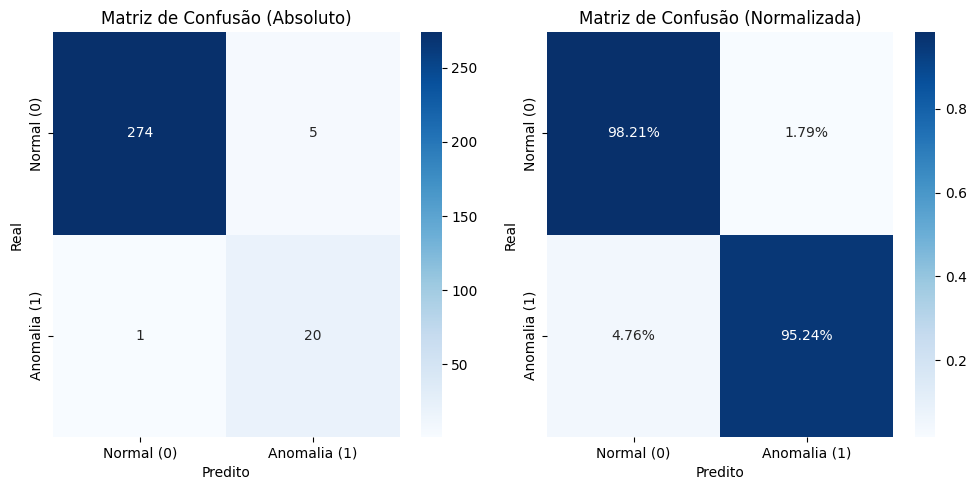


Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       279
    Anomalia       0.80      0.95      0.87        21

    accuracy                           0.98       300
   macro avg       0.90      0.97      0.93       300
weighted avg       0.98      0.98      0.98       300



In [ ]:
# Melhor por F1
best_arch = results_df['F1-Score'].idxmax()
print(f"Melhor modelo (F1-Score): {best_arch}")

best_model, best_edges = models[best_arch]


modelo_IA = 'Bayesian'

if modelo_IA == 'Bayesian':

  model_final, y_pred_final, y_prob_final, metrics_final = train_and_evaluate_bn(
    train_df_nb, test_df_nb, edges_semi, 'Bayesian', 'BDeu', 5
  )
elif modelo_IA == 'hibrido':
  model_final, y_pred_final, y_prob_final, metrics_final  = train_and_evaluate_bn(
    train_df_hier2, test_df_hier2, edges_hybrid, 'Bayesian', 'BDeu', 5
  )
else:
  y_pred_final, y_prob_final, metrics_final = evaluate_sklearn_nb(XGB, X_train_disc, X_test_disc, y_train, y_test, 'XGBClassifier')


# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Valores absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal (0)', 'Anomalia (1)'],
            yticklabels=['Normal (0)', 'Anomalia (1)'])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusão (Absoluto)')

# Valores normalizados
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Normal (0)', 'Anomalia (1)'],
            yticklabels=['Normal (0)', 'Anomalia (1)'])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusão (Normalizada)')

plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Anomalia']))

Best model (F1-Score): Semi-Naive


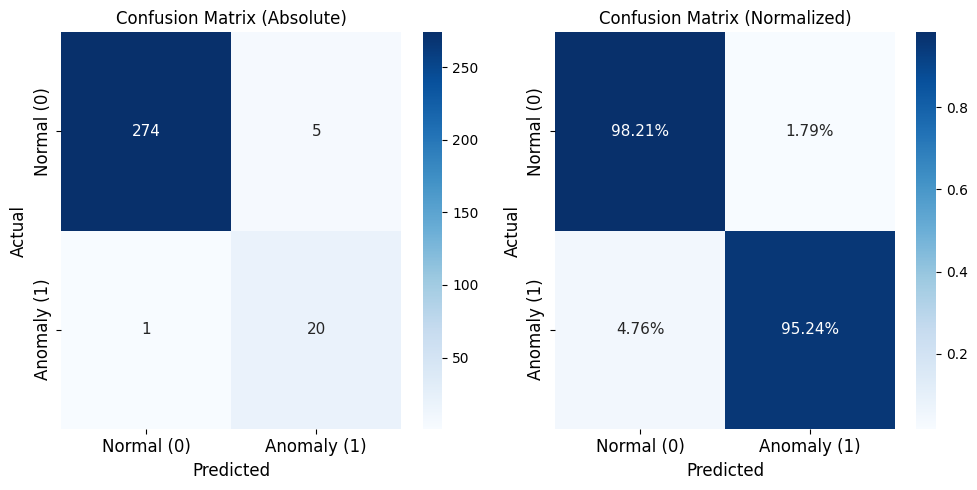


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       279
     Anomaly       0.80      0.95      0.87        21

    accuracy                           0.98       300
   macro avg       0.90      0.97      0.93       300
weighted avg       0.98      0.98      0.98       300



In [ ]:
best_arch = results_df['F1-Score'].idxmax()
print(f"Best model (F1-Score): {best_arch}")

best_model, best_edges = models[best_arch]

# Define AI model type
ai_model = 'Bayesian'

if ai_model == 'Bayesian':
    model_final, y_pred_final, y_prob_final, metrics_final = train_and_evaluate_bn(
        train_df_nb, test_df_nb, edges_semi, 'Bayesian', 'BDeu', 5
    )
elif ai_model == 'hybrid':
    model_final, y_pred_final, y_prob_final, metrics_final = train_and_evaluate_bn(
        train_df_hier2, test_df_hier2, edges_hybrid, 'Bayesian', 'BDeu', 5
    )
else:
    y_pred_final, y_prob_final, metrics_final = evaluate_sklearn_nb(
        XGB, X_train_disc, X_test_disc, y_train, y_test, 'XGBClassifier'
    )

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Absolute values
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'], annot_kws={"size": 11})
axes[0].set_xlabel('Predicted',fontsize=12)
axes[0].set_ylabel('Actual',fontsize=12)
axes[0].set_title('Confusion Matrix (Absolute)',fontsize=12)

# Normalized values
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'],annot_kws={"size": 11})
axes[1].set_xlabel('Predicted',fontsize=12)
axes[1].set_ylabel('Actual',fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)',fontsize=12)
axes[0].tick_params(axis='both', labelsize=12)
axes[1].tick_params(axis='both', labelsize=12)


plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Anomaly']))

## 8. Cálculo de Métricas de Explicabilidade

Vamos calcular a **influência** de cada nó na predição usando múltiplas métricas:
1. **Mutual Information** com o label
2. **KL Divergence** das CPDs (diferença entre P(feature|label=0) e P(feature|label=1))
3. **Feature Importance** baseada em permutação

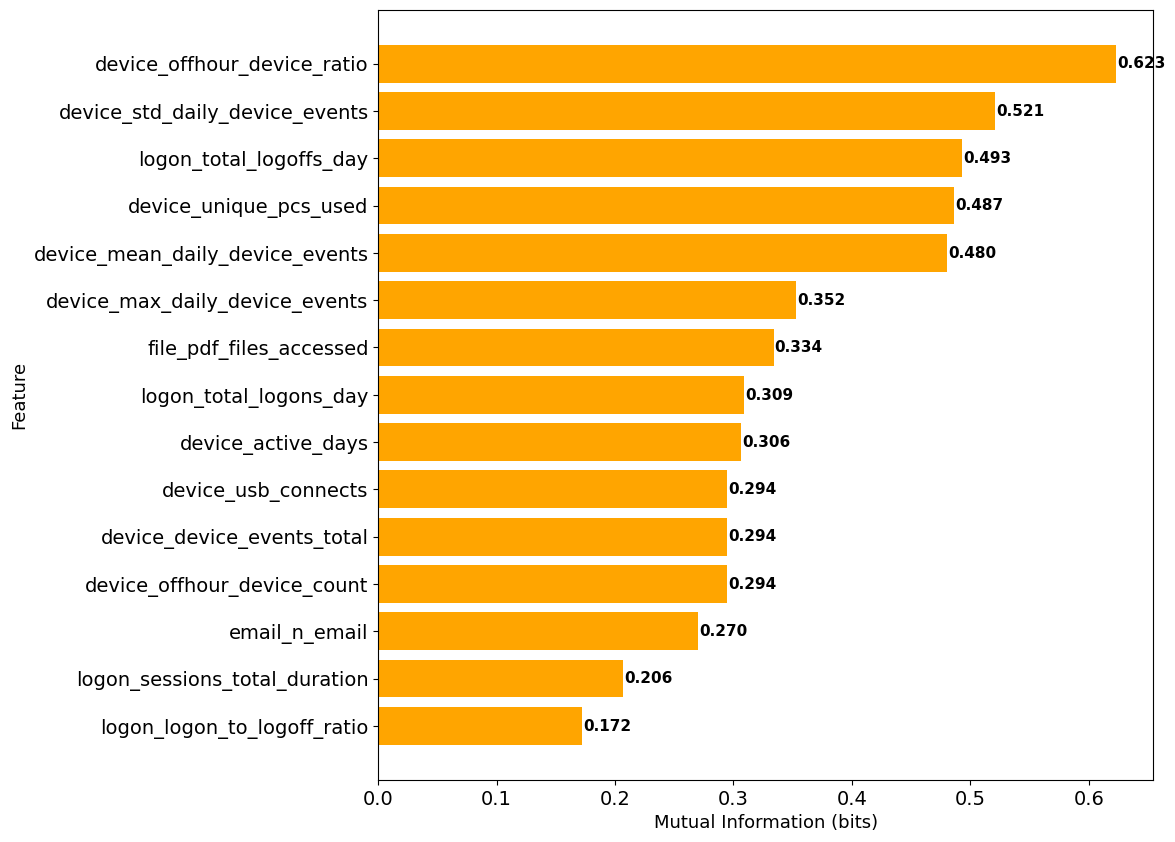

In [ ]:
import numpy as np
import pandas as pd
from math import log
from pgmpy.inference import VariableElimination

def mutual_information(model, feature_node, label_node='label'):
    """
    Calcula a Mutual Information entre um nó (feature_node) e o label_node usando inferência.
    """
    inference = VariableElimination(model)

    # Obter a distribuição conjunta P(feature_node, label_node)
    joint_dist = inference.query([feature_node, label_node], show_progress=False)

    # Extrair os valores da distribuição conjunta
    # joint_dist.values will be P(feature_node, label_node)
    # The order of variables in joint_dist.variables might vary,
    # so we need to ensure correct indexing.
    if joint_dist.variables[0] == feature_node:
        p_xy_values = joint_dist.values
    else: # joint_dist.variables[0] == label_node
        p_xy_values = joint_dist.values.T # Transpose to get feature_node as rows, label_node as columns

    feature_states_count = joint_dist.cardinality[joint_dist.variables.index(feature_node)]
    label_states_count = joint_dist.cardinality[joint_dist.variables.index(label_node)]

    # Marginais
    # P(feature_node)
    p_feature = np.sum(p_xy_values, axis=1)

    # P(label_node)
    p_label = np.sum(p_xy_values, axis=0)

    # Calcular MI
    mi = 0.0
    # Ensure all arrays are float to avoid integer division issues and add epsilon for log(0)
    p_xy_values_float = p_xy_values.astype(float)
    p_feature_float = p_feature.astype(float)
    p_label_float = p_label.astype(float)

    for i in range(feature_states_count):
        for j in range(label_states_count):
            p_xy = p_xy_values_float[i, j]

            # Add a small epsilon to avoid log(0) issues
            if p_xy > 1e-10 and p_feature_float[i] > 1e-10 and p_label_float[j] > 1e-10:
                mi += p_xy * log(p_xy / (p_feature_float[i] * p_label_float[j]), 2)
    return mi

# Lista para armazenar MI
mi_scores_list = [] # Renomeada para evitar conflito com Series mi_scores

# Iterar sobre todas as features
for feat in model_final.nodes():
    if feat == 'label':
        continue

    # Usar a função de MI robusta
    mi = mutual_information(model_final, feat, label_node='label')
    mi_scores_list.append((feat, mi))

# Ordenar por MI
mi_sorted = sorted(mi_scores_list, key=lambda x: x[1], reverse=True)

# Converter em DataFrame
df_mi = pd.DataFrame(mi_sorted, columns=['Feature', 'Mutual Information'])

df_top15 = df_mi.head(15)

# Plotar gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
bars = plt.barh(df_top15['Feature'], df_top15['Mutual Information'], color='orange')
plt.gca().invert_yaxis()
plt.title("",fontsize=14)
plt.xlabel("Mutual Information (bits)",fontsize=13)
plt.ylabel("Feature",fontsize=13)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


# Adicionar valores ao lado das barras
for bar, mi in zip(bars, df_mi['Mutual Information']):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"{mi:.3f}", va='center',fontsize=11,fontweight='bold')

plt.savefig('bits_features.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Visualização da Rede com Explicabilidade

O tamanho dos nós é proporcional à sua **importância/influência** na predição.
A cor indica o **tipo** do nó.

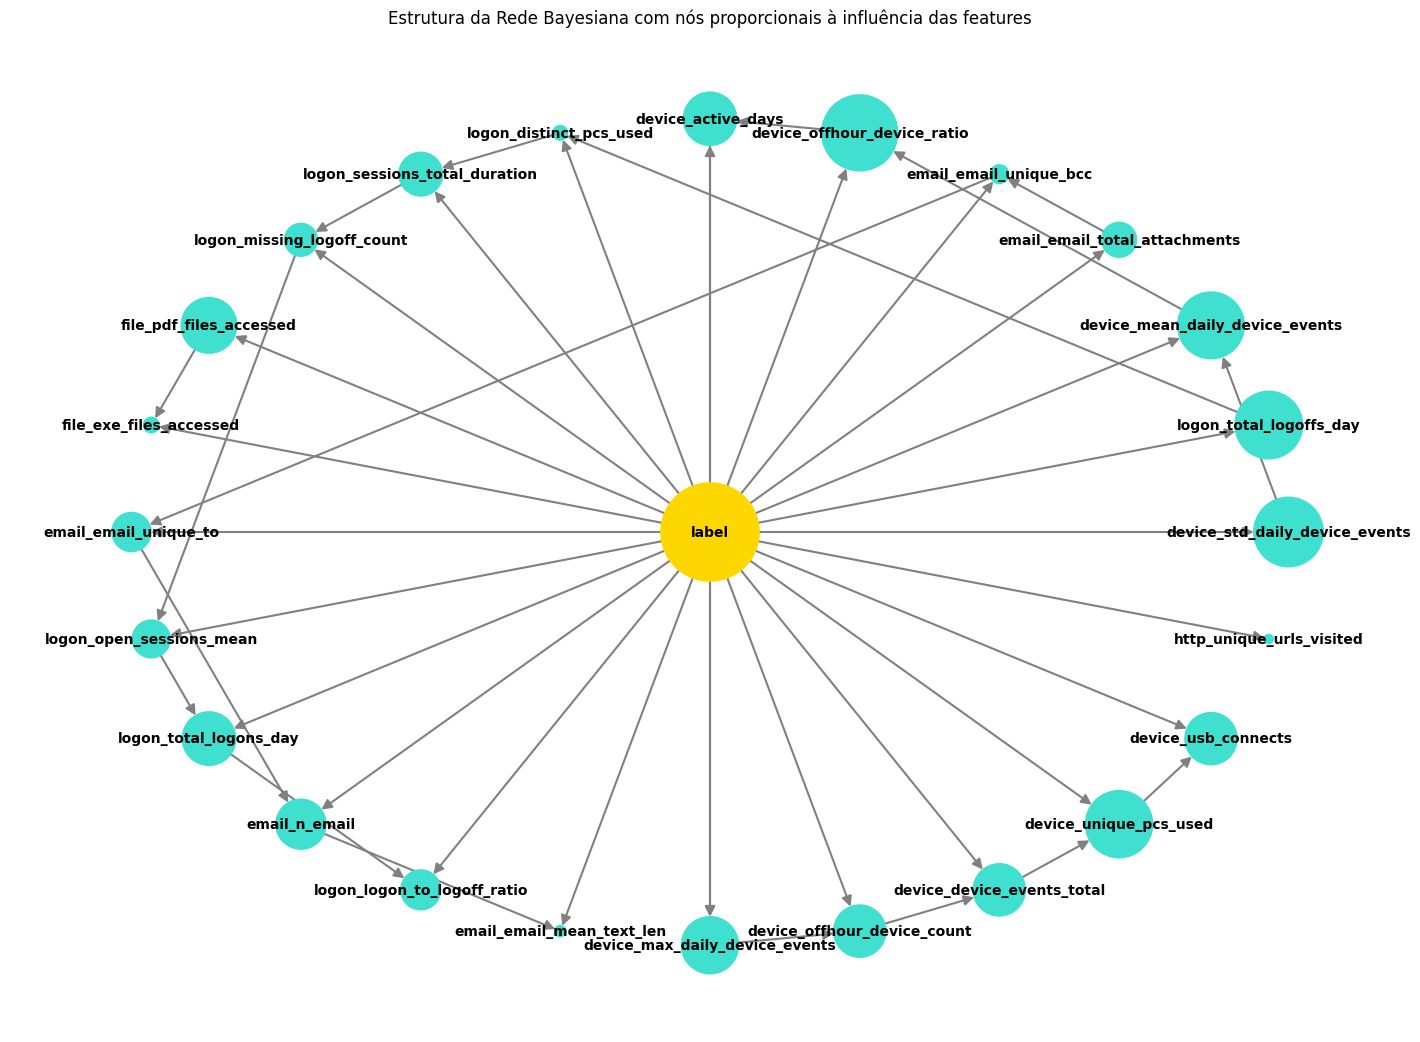

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Suponha que você já tenha os valores de influência das features

mi_sorted

df_influencia = pd.DataFrame(mi_sorted, columns=['Feature', 'Influencia'])

# Criar grafo da rede bayesiana
G = nx.DiGraph()
G.add_edges_from(edges_semi)

# Normalizar os valores de influência para tamanhos de nó
# Multiplicando por um fator para ficar visível
max_infl = df_influencia['Influencia'].max()
node_sizes = {}
for feat, val in zip(df_influencia['Feature'], df_influencia['Influencia']):
    node_sizes[feat] = 3000 * (val / max_infl)  # escala

# O label pode ter tamanho fixo maior
node_sizes['label'] = 5000


# Layout customizado label no centro
pos = {}
pos['label'] = (0, 0)  # Label no centro

n_features = len(top_features)
angles = np.linspace(0, 2*np.pi, n_features, endpoint=False)
radius = 2

for i, feat in enumerate(top_features):
    pos[feat] = (radius * np.cos(angles[i]), radius * np.sin(angles[i]))

# Cores dos nós
node_colors = ['gold' if node == 'label' else 'turquoise' for node in G.nodes()]

# Criar lista de tamanhos na ordem dos nós do grafo
sizes = [node_sizes.get(node, 1000) for node in G.nodes()]

# Plotar grafo
plt.figure(figsize=(14,10))
nx.draw(G, pos,
        with_labels=True,
        node_size=sizes,
        node_color=node_colors,
        font_size=10,
        font_weight='bold',
        arrowsize=15,
        edge_color='gray',
        width=1.5)
plt.title("Estrutura da Rede Bayesiana com nós proporcionais à influência das features")
plt.show()

Visualizando: Semi-Naive


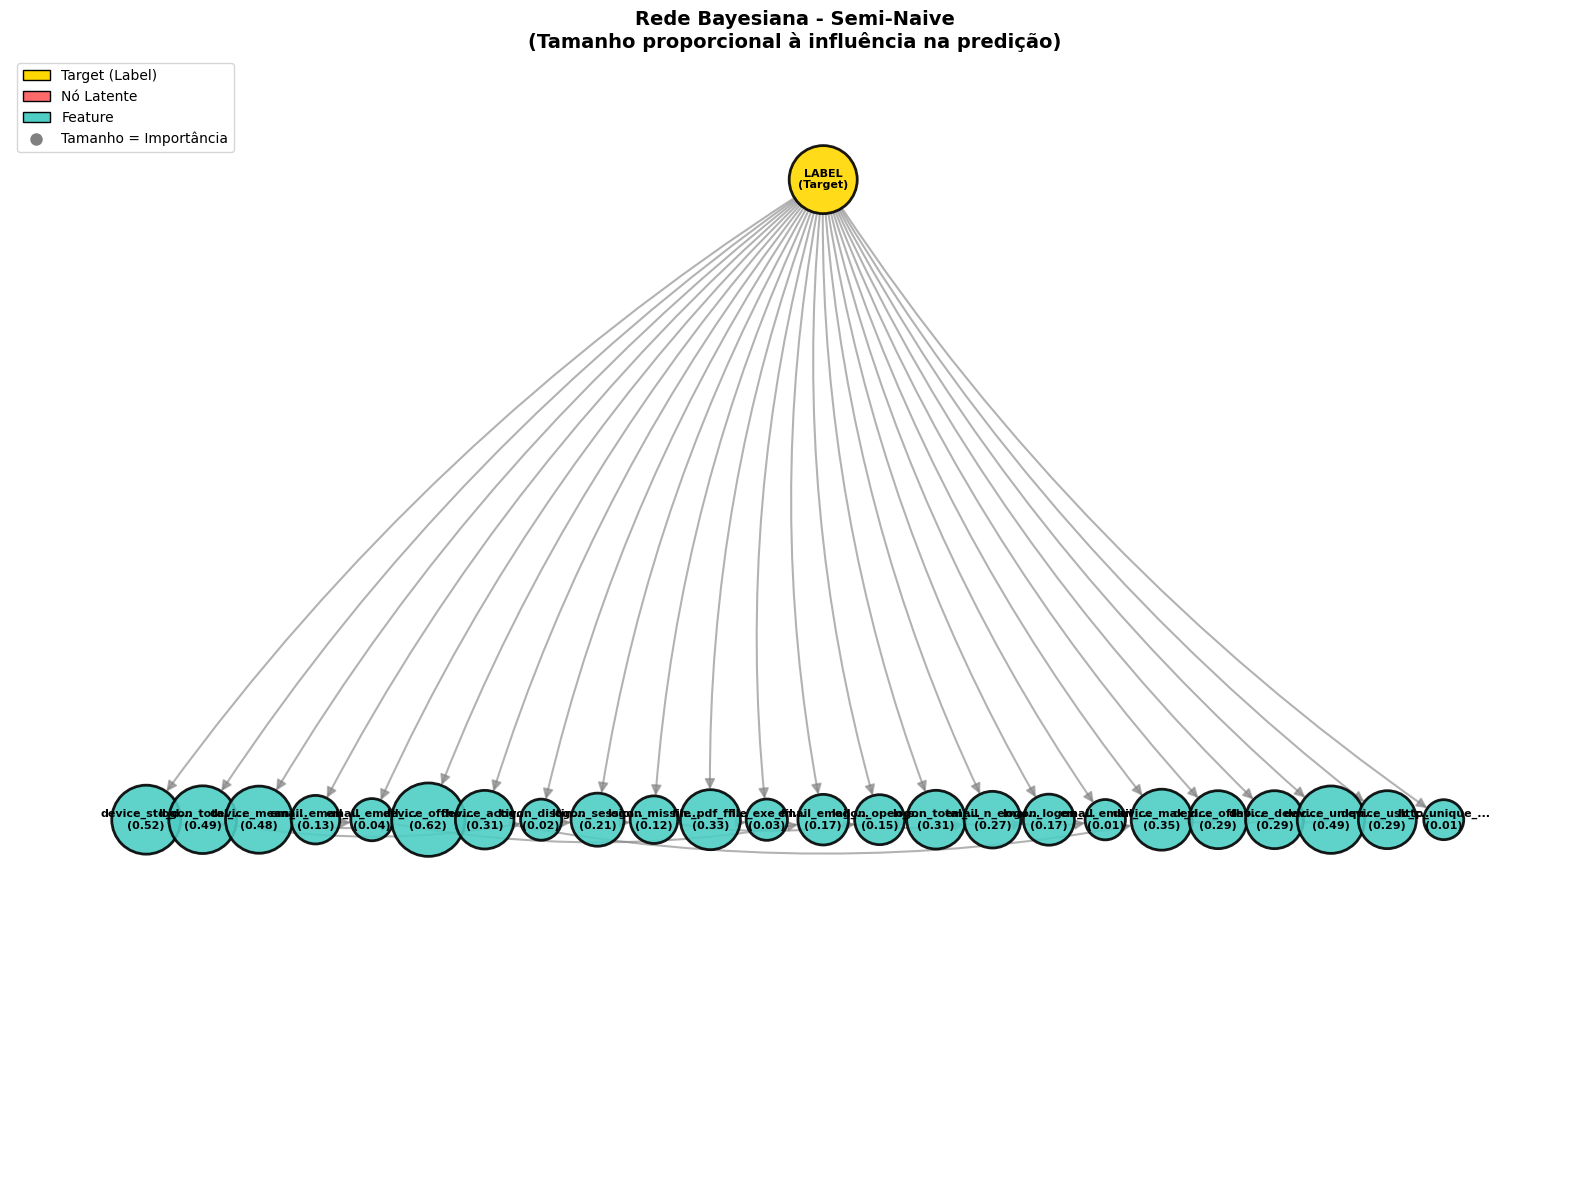

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_bn_with_explainability(model, edges, importance_list, title="Rede Bayesiana",
                                figsize=(16, 12), save_path=None):
    """
    Plota a rede bayesiana com nós dimensionados por importância.
    """

    # Converter lista de tuplas em dict {feat: mi}
    importance_dict = {feat: mi for feat, mi in importance_list}

    G = nx.DiGraph()
    G.add_edges_from(edges)

    node_sizes = []
    node_colors = []

    MIN_SIZE = 800
    MAX_SIZE = 4000

    for node in G.nodes():
        imp = importance_dict.get(node, 0.5)
        node_type = 'feature'
        if node == 'label':
            node_type = 'label'
        elif node.startswith('latent_'):
            node_type = 'latent'

        size = MIN_SIZE + (MAX_SIZE - MIN_SIZE) * imp
        node_sizes.append(size)

        if node_type == 'label':
            node_colors.append('#FFD700')
        elif node_type == 'latent':
            node_colors.append('#FF6B6B')
        else:
            node_colors.append('#4ECDC4')

    # Layout hierárquico
    pos = {}
    latent_nodes = [n for n in G.nodes() if n.startswith('latent_')]
    feature_nodes = [n for n in G.nodes() if not n.startswith('latent_') and n != 'label']

    pos['label'] = (0, 2)
    if latent_nodes:
        for i, node in enumerate(latent_nodes):
            x = (i - len(latent_nodes)/2) * 2
            pos[node] = (x, 1)
    for i, node in enumerate(feature_nodes):
        x = (i - len(feature_nodes)/2) * 1.2
        pos[node] = (x, 0)

    fig, ax = plt.subplots(figsize=figsize)

    # Desenhar arestas com setas até a borda dos nós
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color='gray',
        arrows=True,
        arrowsize=15,
        width=1.5,
        alpha=0.6,
        connectionstyle="arc3,rad=0.1",
        node_size=node_sizes,   # <-- ESSENCIAL para calcular a borda
        arrowstyle='-|>'        # seta mais visível
    )

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_size=node_sizes, node_color=node_colors,
                           edgecolors='black', linewidths=2, alpha=0.9)

    labels = {}
    for node in G.nodes():
        imp = importance_dict.get(node, 0.5)
        if node == 'label':
            labels[node] = 'LABEL\n(Target)'
        else:
            short_name = node[:12] + '...' if len(node) > 12 else node
            labels[node] = f"{short_name}\n({imp:.2f})"

    nx.draw_networkx_labels(G, pos, labels, ax=ax,
                            font_size=8, font_weight='bold')

    legend_elements = [
        mpatches.Patch(facecolor='#FFD700', edgecolor='black', label='Target (Label)'),
        mpatches.Patch(facecolor='#FF6B6B', edgecolor='black', label='Nó Latente'),
        mpatches.Patch(facecolor='#4ECDC4', edgecolor='black', label='Feature'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                   markersize=10, label='Tamanho = Importância')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')

    plt.show()
    return fig

# Plotar rede do melhor modelo
print(f"Visualizando: {best_arch}")
fig = plot_bn_with_explainability(
    best_model, best_edges, mi_sorted,
    title=f"Rede Bayesiana - {best_arch}\n(Tamanho proporcional à influência na predição)",
    save_path='rede_explicabilidade.png'
)

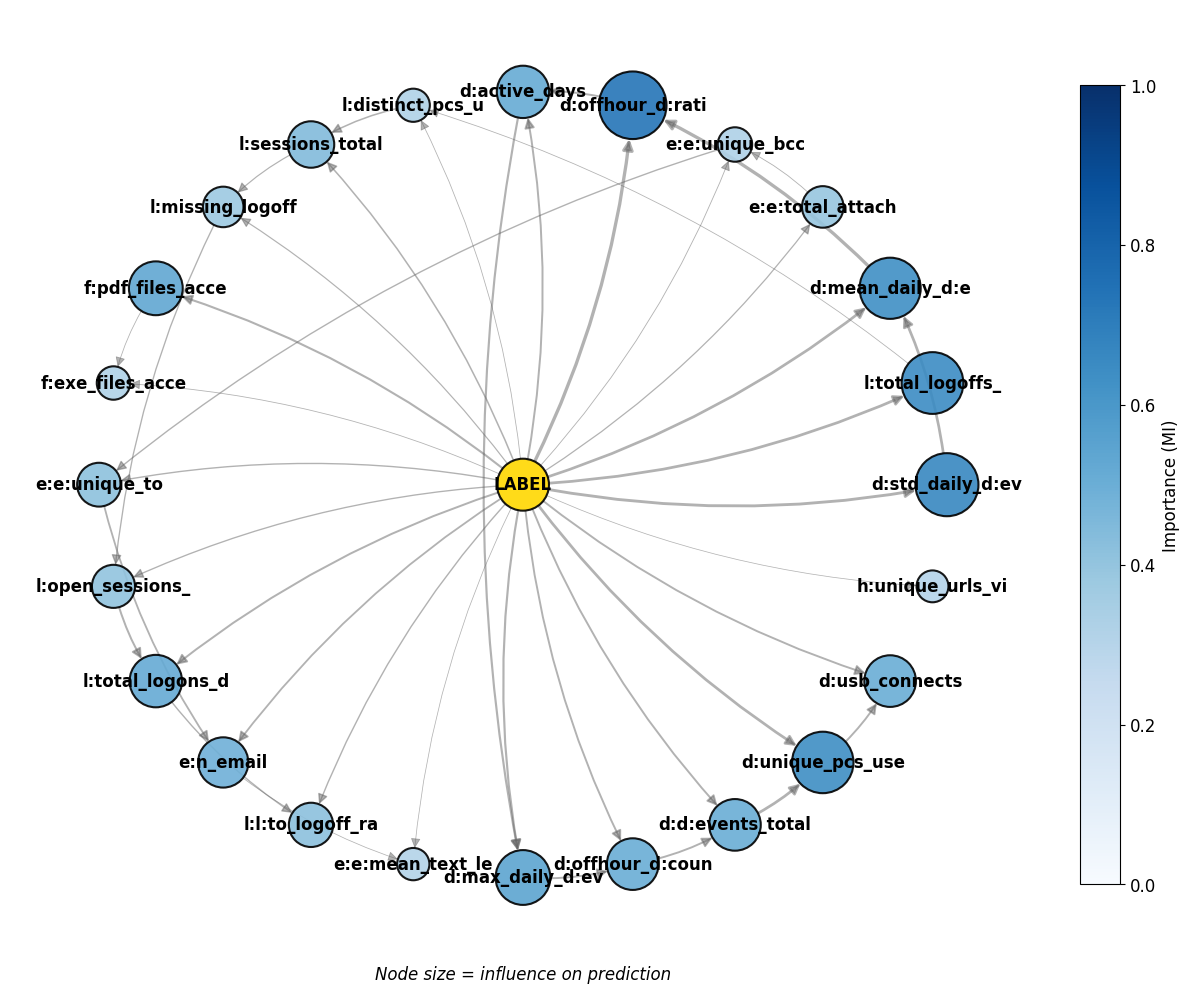

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def plot_bn_circular_explainability(model, edges, importance_list,
                                    title="Bayesian Network",
                                    figsize=(12, 10), save_path=None):
    """
    Plot the network with circular layout, ideal for visualizing importance.

    Parameters:
    -----------
    model : BayesianNetwork
    edges : list of tuples
    importance_list : list of tuples (feat, mi)
                      Example: [("feature1", 0.8), ("feature2", 0.3), ("label", 1.0)]
    """

    # Convert list of tuples into dict {feat: mi}
    importance_dict = {feat: mi for feat, mi in importance_list}

    G = nx.DiGraph()
    G.add_edges_from(edges)

    # Separate nodes by type
    latent_nodes = [n for n in G.nodes() if n.startswith('latent_')]
    feature_nodes = [n for n in G.nodes() if not n.startswith('latent_') and n != 'label']

    # Circular layout
    pos = {}
    pos['label'] = (0, 0)  # Label in the center

    if latent_nodes:
        angles_latent = np.linspace(0, 2*np.pi, len(latent_nodes), endpoint=False)
        radius_latent = 1.5
        for i, node in enumerate(latent_nodes):
            pos[node] = (radius_latent * np.cos(angles_latent[i]),
                         radius_latent * np.sin(angles_latent[i]))

    angles_feat = np.linspace(0, 2*np.pi, len(feature_nodes), endpoint=False)
    radius_feat = 3.5
    for i, node in enumerate(feature_nodes):
        pos[node] = (radius_feat * np.cos(angles_feat[i]),
                     radius_feat * np.sin(angles_feat[i]))

    # Node sizes and colors
    node_sizes = []
    node_colors = []
    edge_widths = []

    MIN_SIZE, MAX_SIZE = 500, 3500

    for node in G.nodes():
        imp = importance_dict.get(node, 0.3)
        node_type = 'feature'
        if node == 'label':
            node_type = 'label'
        elif node.startswith('latent_'):
            node_type = 'latent'

        size = MIN_SIZE + (MAX_SIZE - MIN_SIZE) * min(imp, 1.0)
        node_sizes.append(size)

        if node_type == 'label':
            node_colors.append('#FFD700')
        elif node_type == 'latent':
            node_colors.append('#FF6B6B')
        else:
            intensity = 0.3 + 0.7 * imp
            node_colors.append(plt.cm.Blues(intensity))

    # Edge widths based on importance of target node
    for edge in G.edges():
        target = edge[1]
        imp = importance_dict.get(target, 0.3)
        edge_widths.append(0.5 + 3 * imp)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color='#666666',
        arrows=True,
        arrowsize=15,
        width=edge_widths,
        alpha=0.5,
        style='solid',
        connectionstyle="arc3,rad=0.1",
        node_size=node_sizes,
        arrowstyle='-|>'
    )

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors='black',
        linewidths=1.5,
        alpha=0.9
    )

    # Labels (English, with MI values removed)
    labels = {}
    for node in G.nodes():
        if node == 'label':
            labels[node] = 'LABEL'
        else:
            short = node.replace('latent_', 'L:').replace('device_', 'd:').replace('file_', 'f:')
            short = short.replace('email_', 'e:').replace('logon_', 'l:').replace('http_', 'h:')
            labels[node] = short[:16]  # show name only, no MI

    nx.draw_networkx_labels(
        G, pos, labels, ax=ax,
        font_size=12,
        font_weight='bold'
    )

    # Legend (latent node removed)
    #legend_elements = [
     #   mpatches.Patch(facecolor='#FFD700', edgecolor='black', label='Target (Label)'),
      #  mpatches.Patch(facecolor='#4682B4', edgecolor='black', label='Feature (high importance)'),
      #  mpatches.Patch(facecolor='#B0C4DE', edgecolor='black', label='Feature (low importance)'),
    #]
    #ax.legend(handles=legend_elements, loc='upper left', fontsize=9,  title='Node Type', title_fontsize=12)

    ax.annotate('Node size = influence on prediction',
                xy=(0.5, -0.02), xycoords='axes fraction',
                ha='center', fontsize=12, style='italic')

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')

    sm = cm.ScalarMappable(
    cmap=plt.cm.Blues,
    norm=mcolors.Normalize(vmin=0, vmax=1)  # valores de importância entre 0 e 1
    )
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax, fraction=0.036, pad=0.04)
    cbar.set_label("Importance (MI)", fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=350, bbox_inches='tight', facecolor='white')

    plt.show()
    return fig


# Plotar versão circular
figura = plot_bn_circular_explainability(
    best_model, best_edges, mi_sorted,
    title='',
    save_path='Rede_Bayesian_explicabilidade.png'
)

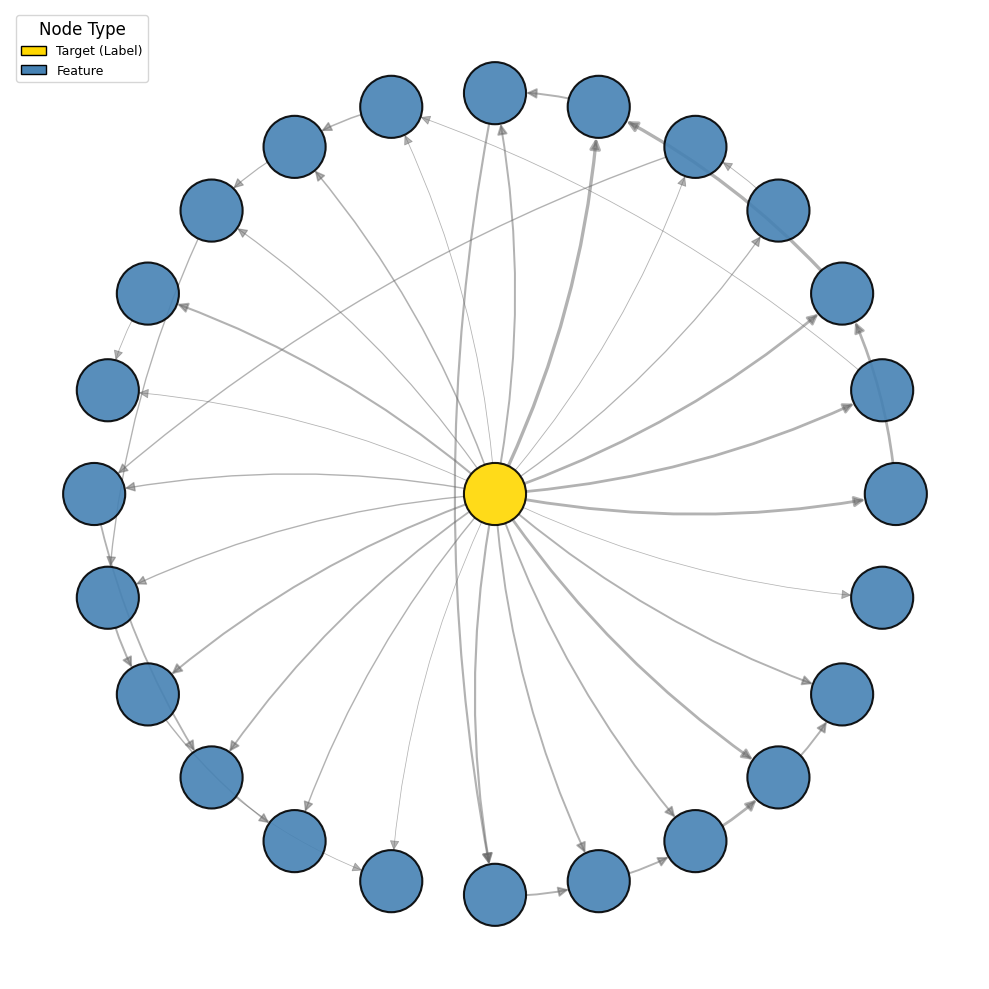

In [ ]:
def plot_bn_circular_explainability(model, edges, importance_list,
                                    title="Bayesian Network",
                                    figsize=(10, 10), save_path=None):
    """
    Plot the network with circular layout, ideal for visualizing importance.

    Parameters:
    -----------
    model : BayesianNetwork
    edges : list of tuples
    importance_list : list of tuples (feat, mi)
                      Example: [("feature1", 0.8), ("feature2", 0.3), ("label", 1.0)]
    """

    # Convert list of tuples into dict {feat: mi}
    importance_dict = {feat: mi for feat, mi in importance_list}

    G = nx.DiGraph()
    G.add_edges_from(edges)

    # Separate nodes by type
    latent_nodes = [n for n in G.nodes() if n.startswith('latent_')]
    feature_nodes = [n for n in G.nodes() if not n.startswith('latent_') and n != 'label']

    # Circular layout
    pos = {}
    pos['label'] = (0, 0)  # Label in the center

    if latent_nodes:
        angles_latent = np.linspace(0, 2*np.pi, len(latent_nodes), endpoint=False)
        radius_latent = 1.5
        for i, node in enumerate(latent_nodes):
            pos[node] = (radius_latent * np.cos(angles_latent[i]),
                         radius_latent * np.sin(angles_latent[i]))

    angles_feat = np.linspace(0, 2*np.pi, len(feature_nodes), endpoint=False)
    radius_feat = 3.5
    for i, node in enumerate(feature_nodes):
        pos[node] = (radius_feat * np.cos(angles_feat[i]),
                     radius_feat * np.sin(angles_feat[i]))

    # Fixed node size
    FIXED_SIZE = 2000
    node_sizes = [FIXED_SIZE for _ in G.nodes()]

    # Colors
    node_colors = []
    for node in G.nodes():
        if node == 'label':
            node_colors.append('#FFD700')
        elif node.startswith('latent_'):
            node_colors.append('#FF6B6B')
        else:
            node_colors.append('#4682B4')

    # Edge widths based on importance of target node
    edge_widths = []
    for edge in G.edges():
        target = edge[1]
        imp = importance_dict.get(target, 0.3)
        edge_widths.append(0.5 + 3 * imp)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color='#666666',
        arrows=True,
        arrowsize=15,
        width=edge_widths,
        alpha=0.5,
        style='solid',
        connectionstyle="arc3,rad=0.1",
        node_size=node_sizes,
        arrowstyle='-|>'
    )

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors='black',
        linewidths=1.5,
        alpha=0.9
    )

    # Labels (without MI values)
    labels = {}
    for node in G.nodes():
        if node == 'label':
            labels[node] = 'LABEL'
        else:
            short = node.replace('latent_', 'L:').replace('device_', 'd:').replace('file_', 'f:')
            short = short.replace('email_', 'e:').replace('logon_', 'l:').replace('http_', 'h:')
            labels[node] = short  # only short name, no MI

    nx.draw_networkx_labels(
        G, pos, labels={}, ax=ax,
        font_size=10,
        font_weight='bold'
    )

    # Legend (without latent nodes)
    legend_elements = [
        mpatches.Patch(facecolor='#FFD700', edgecolor='black', label='Target (Label)'),
        mpatches.Patch(facecolor='#4682B4', edgecolor='black', label='Feature'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9,
              title='Node Type', title_fontsize=12)



    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')

    plt.show()
    return fig





# Plotar versão circular
figura = plot_bn_circular_explainability(
    best_model, best_edges, mi_sorted,
    title='',
    save_path='Arquitetura da rede.png'
)

## 10. Comparação Visual das Arquiteturas

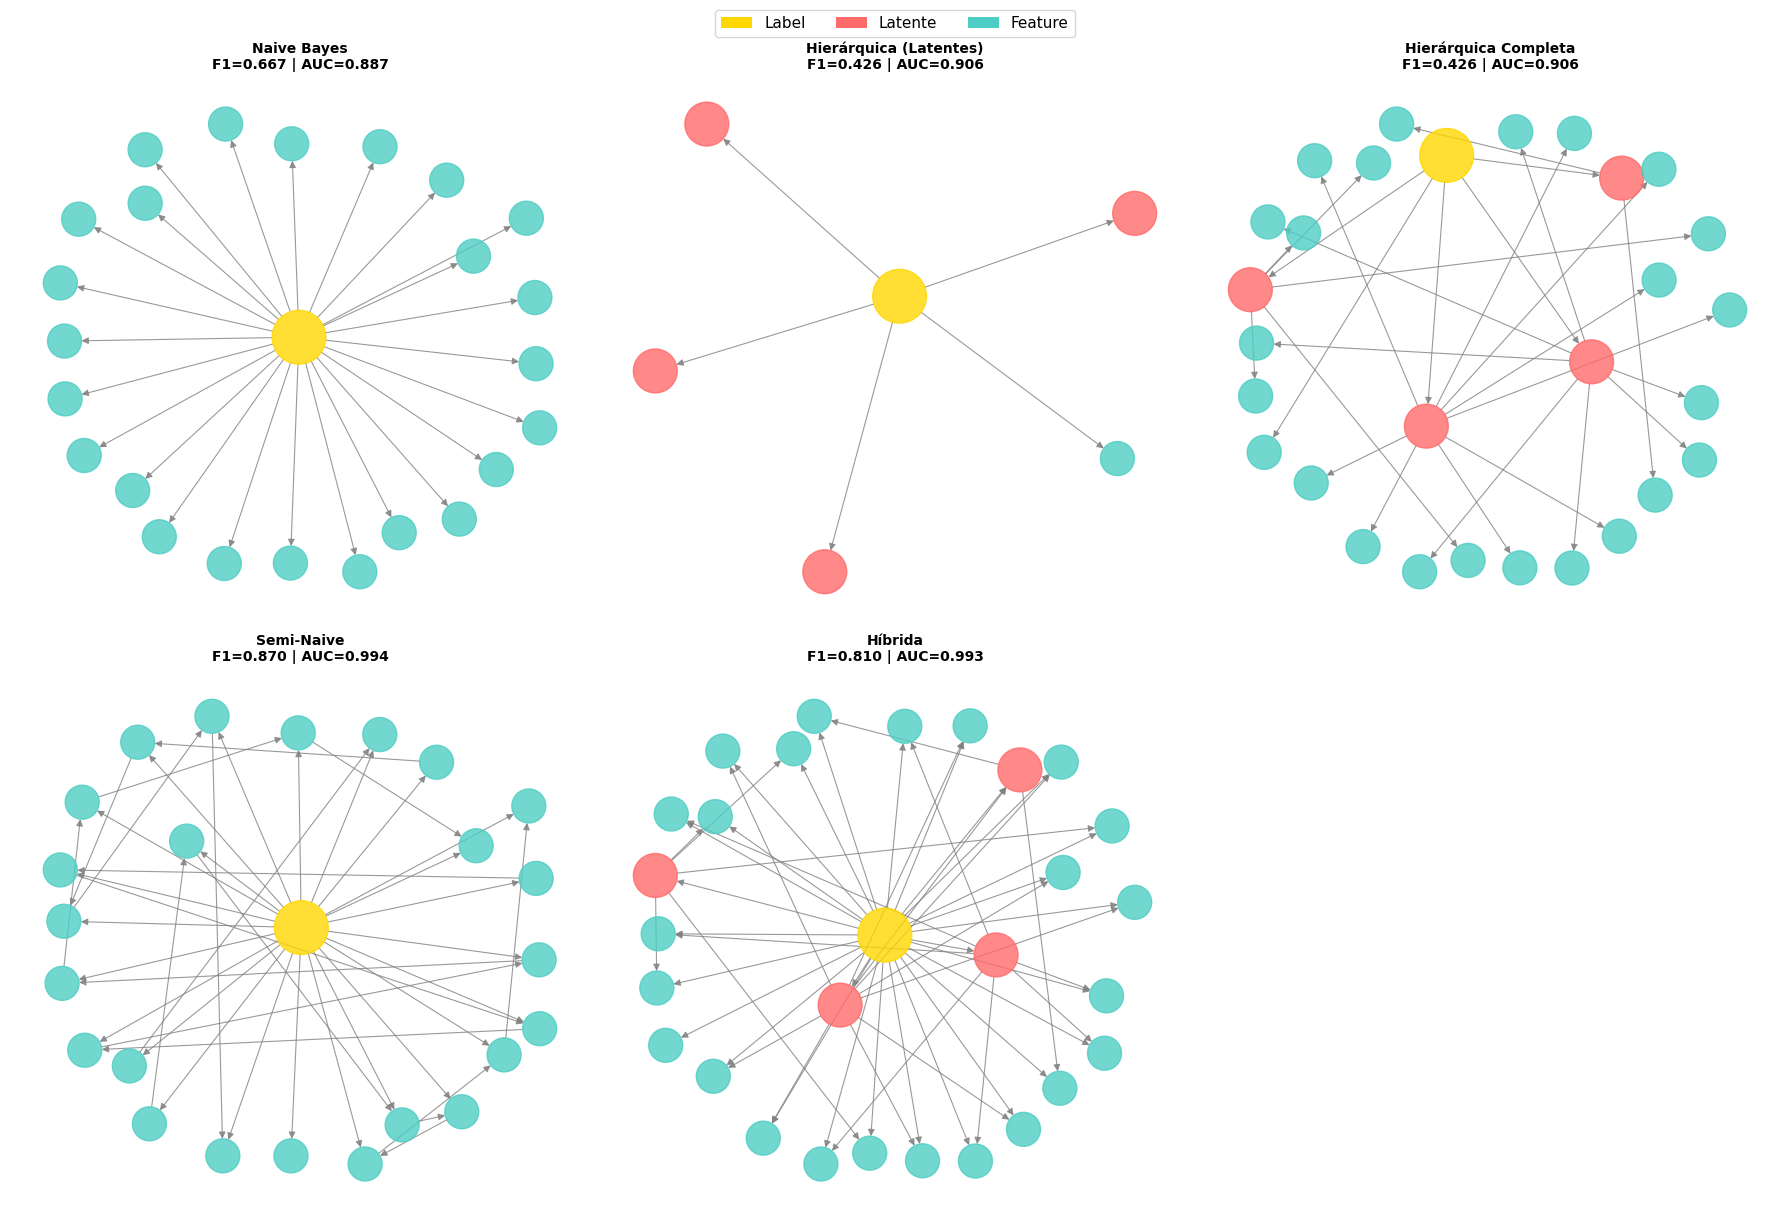

In [ ]:
# Visualizar todas as arquiteturas lado a lado
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

architectures_to_plot = list(models.keys())[:5]  # Primeiras 5 arquiteturas

for idx, (arch_name, (model, edges)) in enumerate(models.items()):
    if idx >= 5:
        break

    ax = axes[idx]
    G = nx.DiGraph()
    G.add_edges_from(edges)

    # Layout simples
    try:
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    except:
        pos = nx.circular_layout(G)

    # Cores
    colors = []
    sizes = []
    for node in G.nodes():
        if node == 'label':
            colors.append('#FFD700')
            sizes.append(1500)
        elif node.startswith('latent_'):
            colors.append('#FF6B6B')
            sizes.append(1000)
        else:
            colors.append('#4ECDC4')
            sizes.append(600)

    nx.draw(G, pos, ax=ax, with_labels=False,
            node_color=colors, node_size=sizes,
            edge_color='gray', arrows=True, arrowsize=10,
            alpha=0.8, width=0.8)

    # Métricas
    metrics = results[arch_name]
    ax.set_title(f"{arch_name}\nF1={metrics['F1-Score']:.3f} | AUC={metrics['ROC-AUC']:.3f}",
                fontsize=10, fontweight='bold')

# Remover subplot vazio
if len(models) < 6:
    axes[-1].axis('off')

# Legenda geral
legend_elements = [
    mpatches.Patch(facecolor='#FFD700', label='Label'),
    mpatches.Patch(facecolor='#FF6B6B', label='Latente'),
    mpatches.Patch(facecolor='#4ECDC4', label='Feature')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.02), fontsize=11)

plt.tight_layout()
plt.savefig('comparacao_arquiteturas_visual.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Análise Detalhada da Explicabilidade

In [ ]:

# Análise das CPDs dos nós mais importantes
print("\n" + "="*70)
print("ANÁLISE DAS CPDs - COMO OS NÓS INFLUENCIAM A PREDIÇÃO")
print("="*70)

top_3_nodes = df_mi.nlargest(3, 'Mutual Information')['Feature'].tolist()
for node in top_3_nodes:
    print(f"\n--- {node} ---")
    try:
        cpd = best_model.get_cpds(node)
        print(cpd)

        if cpd is not None:
            values = cpd.values
            if values.shape[1] >= 2:
                diff = np.abs(values[:, 0] - values[:, 1])
                max_diff_state = np.argmax(np.mean(diff, axis=-1)) if diff.ndim > 1 else np.argmax(diff)
                diff_value = np.max(diff[max_diff_state]) if diff.ndim > 1 else diff[max_diff_state]
                print(f"\n   Interpretação: O estado {max_diff_state} tem a maior diferença")
                print(f"   entre anomalia e normal (diff = {float(diff_value):.3f})")
    except Exception as e:
        print(f"   Erro ao obter CPD: {e}")


ANÁLISE DAS CPDs - COMO OS NÓS INFLUENCIAM A PREDIÇÃO

--- device_offhour_device_ratio ---
+---------------------------------+-----+
| device_mean_daily_device_events | ... |
+---------------------------------+-----+
| label                           | ... |
+---------------------------------+-----+
| device_offhour_device_ratio(0)  | ... |
+---------------------------------+-----+
| device_offhour_device_ratio(1)  | ... |
+---------------------------------+-----+
| device_offhour_device_ratio(2)  | ... |
+---------------------------------+-----+

   Interpretação: O estado 1 tem a maior diferença
   entre anomalia e normal (diff = 0.668)

--- device_std_daily_device_events ---
+-----------------------------------+-----+--------------------+
| label                             | ... | label(1)           |
+-----------------------------------+-----+--------------------+
| device_std_daily_device_events(0) | ... | 0.0721763085399449 |
+-----------------------------------+-----+---------

### 12. Resumo e Conclusões

In [ ]:
print("="*80)
print("RESUMO DA ANÁLISE - REDES BAYESIANAS COM ARQUITETURAS AVANÇADAS")
print("="*80)

print("\n📊 CONFIGURAÇÃO:")
print(f"   • Features selecionadas: Top-20")
print(f"   • Discretização: {STRATEGY} com {N_BINS} bins")
print(f"   • Nós latentes criados: {len(latent_names)}")
print(f"   • Estados por latente: {N_LATENT_STATES}")

print("\n🏆 RANKING DE ARQUITETURAS (por F1-Score):")
ranking = results_df.sort_values('F1-Score', ascending=False)
for i, (arch, row) in enumerate(ranking.iterrows(), 1):
    medal = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"   {medal} {i}. {arch}: F1={row['F1-Score']:.4f}, AUC={row['ROC-AUC']:.4f}")

print("\n🔍 NÓDULOS MAIS INFLUENTES:")
top_5_nodes = df_mi.nlargest(5, 'Mutual Information')['Feature'].tolist()
for node in top_5_nodes:
    # Aqui você pode definir a lógica de emoji se quiser diferenciar tipos
    emoji = "🔵"
    mi_value = df_mi.loc[df_mi['Feature'] == node, 'Mutual Information'].values[0]
    print(f"   {emoji} {node}: {mi_value:.4f}")

print("\n💡 INSIGHTS:")
best_f1 = ranking.iloc[0]['F1-Score']
baseline_f1 = results['Naive Bayes']['F1-Score']
improvement = ((best_f1 - baseline_f1) / baseline_f1) * 100 if baseline_f1 > 0 else 0

print(f"   • Melhor arquitetura: {ranking.index[0]}")
print(f"   • Melhoria sobre Naive Bayes: {improvement:+.1f}%")
print(f"   • Nós latentes capturam padrões agregados de comportamento")


RESUMO DA ANÁLISE - REDES BAYESIANAS COM ARQUITETURAS AVANÇADAS

📊 CONFIGURAÇÃO:
   • Features selecionadas: Top-20
   • Discretização: quantile com 5 bins
   • Nós latentes criados: 4
   • Estados por latente: 3

🏆 RANKING DE ARQUITETURAS (por F1-Score):
   🥇 1. Semi-Naive: F1=0.8696, AUC=0.9944
   🥈 2. Híbrida: F1=0.8095, AUC=0.9928
   🥉 3. Naive Bayes: F1=0.6667, AUC=0.8870
      4. Hierárquica Completa: F1=0.4262, AUC=0.9058
      5. Hierárquica (Latentes): F1=0.4262, AUC=0.9058

🔍 NÓDULOS MAIS INFLUENTES:
   🔵 device_offhour_device_ratio: 0.6234
   🔵 device_std_daily_device_events: 0.5207
   🔵 logon_total_logoffs_day: 0.4927
   🔵 device_unique_pcs_used: 0.4866
   🔵 device_mean_daily_device_events: 0.4802

💡 INSIGHTS:
   • Melhor arquitetura: Semi-Naive
   • Melhoria sobre Naive Bayes: +30.4%
   • Nós latentes capturam padrões agregados de comportamento


In [ ]:
# Salvar resultados
results_df.to_csv('resultados_arquiteturas.csv')

print("\n Arquivos salvos:")
print("   • resultados_arquiteturas.csv")
print("   • rede_explicabilidade.png")
print("   • rede_circular_explicabilidade.png")
print("   • comparacao_arquiteturas.png")
print("   • comparacao_arquiteturas_visual.png")


 Arquivos salvos:
   • resultados_arquiteturas.csv
   • rede_explicabilidade.png
   • rede_circular_explicabilidade.png
   • comparacao_arquiteturas.png
   • comparacao_arquiteturas_visual.png


#Validação Cruzada

In [ ]:
# Carregamento dos dados de treino
X_train = pd.read_csv('/content/X_train.csv')
X_test  = pd.read_csv('/content/X_test.csv')
y_train = pd.read_csv('/content/y_train.csv').squeeze()
y_test  = pd.read_csv('/content/y_test.csv').squeeze()

# Adicionar coluna target em cada conjunto
train_df = X_train.copy()
train_df['label'] = y_train

test_df = X_test.copy()
test_df['label'] = y_test

# Concatenar em um único DataFrame
full_df_treino = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

X_treino = full_df_treino.drop(columns=['label'])
y_treino = full_df_treino['label']

print(f"Treino: {X_treino.shape[0]} amostras, {X_treino.shape[1]} features")
print(f"\nDistribuição das classes (treino):")
print(y_treino.value_counts())
print()


Treino: 14781 amostras, 60 features

Distribuição das classes (treino):
label
0    12139
1     2642
Name: count, dtype: int64



In [ ]:
# Mapeamento de features por domínio comportamental
DOMAIN_MAPPING = {
    'logon': [col for col in X_treino.columns if col.startswith('logon_')],
    'device': [col for col in X_treino.columns if col.startswith('device_')],
    'email': [col for col in X_treino.columns if col.startswith('email_')],
    'file': [col for col in X_treino.columns if col.startswith('file_')],
    'http': [col for col in X_treino.columns if col.startswith('http_')],
    'web': [col for col in X_train.columns if col.startswith('web_')],
}

# Adicionar if_score como feature especial
if 'if_score' in X_treino.columns:
    DOMAIN_MAPPING['anomaly_score'] = ['if_score']

print("Domínios comportamentais identificados:")
for domain, features in DOMAIN_MAPPING.items():
    print(f"  {domain}: {len(features)} features")

Domínios comportamentais identificados:
  logon: 9 features
  device: 13 features
  email: 9 features
  file: 14 features
  http: 3 features
  web: 11 features


In [ ]:
# Carregamento dos dados de teste sem balanceamento
X_train_v = pd.read_csv('/content/X_train_v.csv')
X_test_v  = pd.read_csv('/content/X_test_v.csv')
y_train_v = pd.read_csv('/content/y_train_v.csv').squeeze()
y_test_v  = pd.read_csv('/content/y_test_v.csv').squeeze()

train_df_v = X_train_v.copy()
train_df_v['label'] = y_train_v

test_df_v = X_test_v.copy()
test_df_v['label'] = y_test_v

# Concatenar em um único DataFrame
full_df_teste = pd.concat([train_df_v, test_df_v], axis=0).reset_index(drop=True)

X_teste = full_df_teste.drop(columns=['label'])
y_teste = full_df_teste['label']

print(f"Teste: {X_teste.shape[0]} amostras, {X_teste.shape[1]} features")
print(f"\nDistribuição das classes (teste):")
print(y_teste.value_counts())


features_XGB = ['device_std_daily_device_events','logon_total_logoffs_day','device_mean_daily_device_events','email_email_total_attachments','email_email_unique_bcc',
               'device_offhour_device_ratio','device_active_days','logon_distinct_pcs_used','logon_sessions_total_duration',
               'logon_missing_logoff_count','file_pdf_files_accessed','file_exe_files_accessed','email_email_unique_to','logon_open_sessions_mean',
               'logon_total_logons_day','email_n_email','logon_logon_to_logoff_ratio','email_email_mean_text_len', 'device_max_daily_device_events', 'device_offhour_device_count',
               'device_device_events_total', 'device_unique_pcs_used','device_usb_connects', 'web_web_access_count']

X_train_sel = X_treino[features_XGB].copy()
X_test_sel  = X_teste[features_XGB].copy()

print(f"\nShape de treino após seleção: {X_train_sel.shape}")

Teste: 50510 amostras, 58 features

Distribuição das classes (teste):
label
0    50499
1       11
Name: count, dtype: int64

Shape de treino após seleção: (14781, 24)


In [ ]:
# Carregamento dos dados de teste com balanceamento 10%
X_train_v = pd.read_csv('/content/X_train_v.csv')
X_test_v  = pd.read_csv('/content/X_test_v.csv')
y_train_v = pd.read_csv('/content/y_train_v.csv').squeeze()
y_test_v  = pd.read_csv('/content/y_test_v.csv').squeeze()

train_df_v = X_train_v.copy()
train_df_v['label'] = y_train_v

test_df_v = X_test_v.copy()
test_df_v['label'] = y_test_v

# Concatenar em um único DataFrame
full_df_teste = pd.concat([train_df_v, test_df_v], axis=0).reset_index(drop=True)

X_teste = full_df_teste.drop(columns=['label'])
y_teste = full_df_teste['label']

print(f"Teste: {X_teste.shape[0]} amostras, {X_teste.shape[1]} features")


# balanceando
smote = SMOTEN(random_state=42,sampling_strategy=0.1,k_neighbors=2)
X_res, y_res = smote.fit_resample(X_teste, y_teste)
teste_bal = pd.concat([pd.DataFrame(X_res, columns=X_train.columns),
                       pd.Series(y_res, name='label')], axis=1)

print("Distribuição original:", y_teste.value_counts().to_dict())
print("Distribuição após SMOTEN:", y_res.value_counts().to_dict())


X_teste = teste_bal.drop(columns=['label'])
y_teste = teste_bal['label']

'if_score'
features_XGB = ['device_std_daily_device_events','logon_total_logoffs_day','device_mean_daily_device_events','email_email_total_attachments','email_email_unique_bcc',
               'device_offhour_device_ratio','device_active_days','logon_distinct_pcs_used','logon_sessions_total_duration',
               'logon_missing_logoff_count','file_pdf_files_accessed','file_exe_files_accessed','email_email_unique_to','logon_open_sessions_mean',
               'logon_total_logons_day','http_unique_urls_visited','email_n_email','logon_logon_to_logoff_ratio','email_email_mean_text_len', 'device_max_daily_device_events', 'device_offhour_device_count',
               'device_device_events_total', 'device_unique_pcs_used','http_total_http_events','device_usb_connects']


X_train_sel = X_treino[features_XGB].copy()
X_test_sel  = X_teste[features_XGB].copy()
print(f"\nShape de treino após seleção: {X_train_sel.shape}")

Teste: 4000 amostras, 48 features
Distribuição original: {0: 3995, 1: 5}
Distribuição após SMOTEN: {0: 3995, 1: 399}

Shape de treino após seleção: (1251, 26)


In [ ]:
def discretize_data(X_train, X_test, n_bins=5, strategy='quantile'):
    """
    Discretiza os dados usando KBinsDiscretizer.
    """
    discretizer = KBinsDiscretizer(
        n_bins=n_bins,
        encode='ordinal',
        strategy=strategy,
        subsample=None
    )

    X_train_disc = pd.DataFrame(
        discretizer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    ).astype(int)

    X_test_disc = pd.DataFrame(
        discretizer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    ).astype(int)

    return X_train_disc, X_test_disc, discretizer

# Discretização
N_BINS = 5
STRATEGY = 'quantile'


X_train_disc, X_test_disc, discretizer = discretize_data(
    X_train_sel, X_test_sel,
    n_bins=N_BINS,
    strategy=STRATEGY
)

print(f"Discretização: {STRATEGY} com {N_BINS} bins")
print(f"Shape: {X_train_disc.shape}")

Discretização: quantile com 5 bins
Shape: (14781, 24)


In [ ]:
def create_latent_features(X_disc, domain_mapping, top_features, n_latent_states=3):
    """
    Cria features latentes agregando features de cada domínio usando clustering.

    Parameters:
    -----------
    X_disc : DataFrame - dados discretizados
    domain_mapping : dict - mapeamento domínio -> features
    top_features : list - features selecionadas
    n_latent_states : int - número de estados para cada nó latente

    Returns:
    --------
    X_with_latent : DataFrame com features latentes adicionadas
    latent_names : lista de nomes das features latentes
    feature_to_latent : mapeamento feature -> latente
    """
    X_latent = X_disc.copy()
    latent_names = []
    feature_to_latent = {}
    kmeans_models = {}

    for domain, all_domain_features in domain_mapping.items():
        # Filtrar apenas features que estão no top_features
        domain_features = [f for f in all_domain_features if f in top_features]

        if len(domain_features) >= 2:  # Só cria latente se tiver 2+ features
            latent_name = f'latent_{domain}'

            # Usar KMeans para criar estados latentes
            domain_data = X_disc[domain_features].values
            kmeans = KMeans(n_clusters=n_latent_states, random_state=42, n_init=10)
            X_latent[latent_name] = kmeans.fit_predict(domain_data)

            latent_names.append(latent_name)
            kmeans_models[latent_name] = kmeans

            # Mapear features para este latente
            for feat in domain_features:
                feature_to_latent[feat] = latent_name

            print(f"Criado {latent_name}: {len(domain_features)} features -> {n_latent_states} estados")

    return X_latent, latent_names, feature_to_latent, kmeans_models

# Criar features latentes
N_LATENT_STATES = 3

X_train_latent, latent_names, feature_to_latent, kmeans_models = create_latent_features(
    X_train_disc, DOMAIN_MAPPING, features_XGB, N_LATENT_STATES
)

# Aplicar aos dados de teste
X_test_latent = X_test_disc.copy()
for domain, features in DOMAIN_MAPPING.items():
    domain_features = [f for f in features if f in features_XGB]
    latent_name = f'latent_{domain}'
    if latent_name in kmeans_models:
        X_test_latent[latent_name] = kmeans_models[latent_name].predict(
            X_test_disc[domain_features].values
        )

print(f"\nFeatures latentes criadas: {latent_names}")

Criado latent_logon: 7 features -> 3 estados
Criado latent_device: 9 features -> 3 estados
Criado latent_email: 5 features -> 3 estados
Criado latent_file: 2 features -> 3 estados

Features latentes criadas: ['latent_logon', 'latent_device', 'latent_email', 'latent_file']


In [ ]:
# Preparar dados para cada arquitetura
print("="*70)
print("COMPARAÇÃO DE ARQUITETURAS")
print("="*70)

results = {}
models = {}

# 1. NAIVE BAYES (baseline)
print("\n1. Treinando Naive Bayes (baseline)...")
train_df_nb = X_train_disc.copy()
train_df_nb['label'] = y_treino.values
test_df_nb = X_test_disc.copy()
test_df_nb['label'] = y_teste.values

edges_nb = create_naive_bayes_edges(features_XGB)
model_nb, y_pred_nb, y_prob_nb, metrics_nb = train_and_evaluate_bn(
    train_df_nb, test_df_nb, edges_nb, 'MLE'
)
results['Naive Bayes'] = metrics_nb
models['Naive Bayes'] = (model_nb, edges_nb)
print(f"   F1: {metrics_nb['F1-Score']:.4f}, AUC: {metrics_nb['ROC-AUC']:.4f}")

# 2. HIERÁRQUICA
print("\n2. Treinando Hierárquica (com latentes)...")
# Usar dados com latentes, mas remover features originais que têm latentes
features_for_hier = [f for f in features_XGB if f not in feature_to_latent]
features_hier = features_for_hier + latent_names

train_df_hier = X_train_latent[features_hier].copy()
train_df_hier['label'] = y_treino.values
test_df_hier = X_test_latent[features_hier].copy()
test_df_hier['label'] = y_teste.values

edges_hier = [('label', f) for f in features_hier]
model_hier, y_pred_hier, y_prob_hier, metrics_hier = train_and_evaluate_bn(
    train_df_hier, test_df_hier, edges_hier, 'Bayesian', 'BDeu', 5
)
results['Hierárquica (Latentes)'] = metrics_hier
models['Hierárquica (Latentes)'] = (model_hier, edges_hier)
print(f"   F1: {metrics_hier['F1-Score']:.4f}, AUC: {metrics_hier['ROC-AUC']:.4f}")

# 3. HIERÁRQUICA COMPLETA (latentes + features)
print("\n3. Treinando Hierárquica Completa...")
all_features_hier = features_XGB + latent_names
train_df_hier2 = X_train_latent[all_features_hier].copy()
train_df_hier2['label'] = y_treino.values
test_df_hier2 = X_test_latent[all_features_hier].copy()
test_df_hier2['label'] = y_teste.values

edges_hier2 = create_hierarchical_edges(features_XGB, latent_names, feature_to_latent)
model_hier2, y_pred_hier2, y_prob_hier2, metrics_hier2 = train_and_evaluate_bn(
    train_df_hier2, test_df_hier2, edges_hier2, 'Bayesian', 'BDeu', 5
)
results['Hierárquica Completa'] = metrics_hier2
models['Hierárquica Completa'] = (model_hier2, edges_hier2)
print(f"   F1: {metrics_hier2['F1-Score']:.4f}, AUC: {metrics_hier2['ROC-AUC']:.4f}")

# 4. SEMI-NAIVE
print("\n4. Treinando Semi-Naive (dependências intra-domínio)...")
edges_semi = create_semi_naive_edges(features_XGB, feature_to_latent)
model_semi, y_pred_semi, y_prob_semi, metrics_semi = train_and_evaluate_bn(
    train_df_nb, test_df_nb, edges_semi, 'Bayesian', 'BDeu', 5
)
results['Semi-Naive'] = metrics_semi
models['Semi-Naive'] = (model_semi, edges_semi)
print(f"   F1: {metrics_semi['F1-Score']:.4f}, AUC: {metrics_semi['ROC-AUC']:.4f}")

# 5. HÍBRIDA
print("\n5. Treinando Híbrida...")
edges_hybrid = create_hybrid_edges(features_XGB, latent_names, feature_to_latent)
model_hybrid, y_pred_hybrid, y_prob_hybrid, metrics_hybrid = train_and_evaluate_bn(
    train_df_hier2, test_df_hier2, edges_hybrid, 'Bayesian', 'BDeu', 5
)
results['Híbrida'] = metrics_hybrid
models['Híbrida'] = (model_hybrid, edges_hybrid)
print(f"   F1: {metrics_hybrid['F1-Score']:.4f}, AUC: {metrics_hybrid['ROC-AUC']:.4f}")

COMPARAÇÃO DE ARQUITETURAS

1. Treinando Naive Bayes (baseline)...
   F1: 0.0182, AUC: 0.9091

2. Treinando Hierárquica (com latentes)...
   F1: 0.0044, AUC: 0.8430

3. Treinando Hierárquica Completa...
   F1: 0.0044, AUC: 0.8430

4. Treinando Semi-Naive (dependências intra-domínio)...
   F1: 0.0269, AUC: 0.9634

5. Treinando Híbrida...
   F1: 0.0218, AUC: 0.9066


In [ ]:
# Tabela de resultados
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("\n" + "="*80)
print("RESULTADOS - Comparaç\u00e3o de Arquiteturas")
print("="*80)
print(results_df.to_string())

# Melhor por F1
best_arch = results_df['F1-Score'].idxmax()
print(f"\n🏆 Melhor arquitetura (F1-Score): {best_arch}")


RESULTADOS - Comparação de Arquiteturas
                        Accuracy  Precision  Recall  F1-Score  ROC-AUC   AUPRC  Train Time (s)  Inference Time (s)
Naive Bayes               0.9893     0.0093  0.4545    0.0182   0.9091  0.0171          0.1255            417.3219
Hierárquica (Latentes)    0.9732     0.0022  0.2727    0.0044   0.8430  0.0013          0.0204            133.4839
Hierárquica Completa      0.9732     0.0022  0.2727    0.0044   0.8430  0.0013          0.1021            447.8068
Semi-Naive                0.9886     0.0137  0.7273    0.0269   0.9634  0.0410          0.1077            527.1291
Híbrida                   0.9875     0.0111  0.6364    0.0218   0.9066  0.0522          0.1276            594.0185

🏆 Melhor arquitetura (F1-Score): Semi-Naive


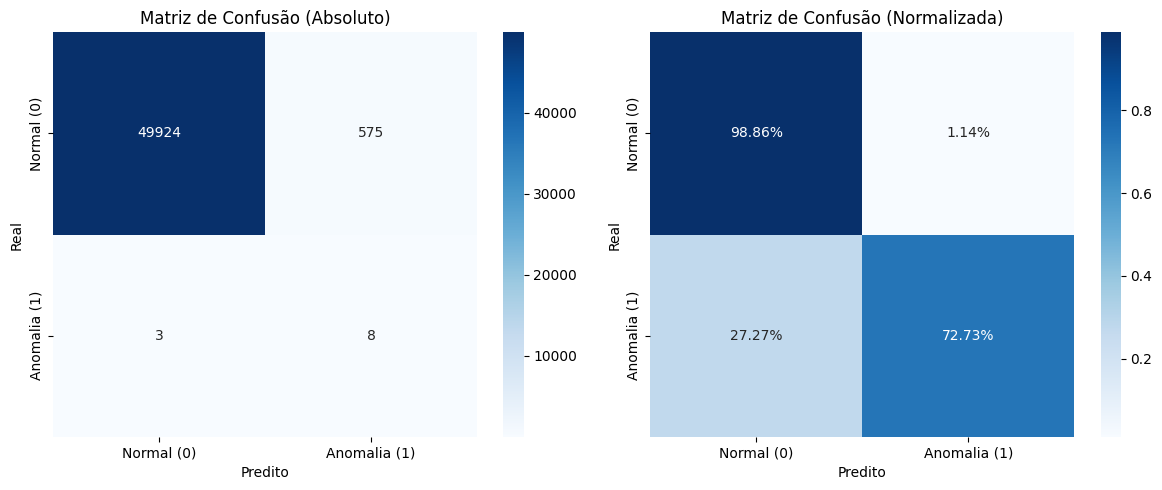


Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     50499
    Anomalia       0.01      0.73      0.03        11

    accuracy                           0.99     50510
   macro avg       0.51      0.86      0.51     50510
weighted avg       1.00      0.99      0.99     50510



In [ ]:

modelo_IA = 'Bayesian'

if modelo_IA == 'Bayesian':

  model_final, y_pred_final, y_prob_final, metrics_final = train_and_evaluate_bn(train_df_nb, test_df_nb, edges_semi, 'Bayesian', 'BDeu', 5)
  #model_final, y_pred_final, y_prob_final, metrics_final = train_and_evaluate_bn(train_df_hier2, test_df_hier2, edges_hybrid, 'Bayesian', 'BDeu', 5)
else:
  XGB = XGBClassifier()
  y_pred_final, y_prob_final, metrics_final = evaluate_sklearn_nb(XGB, X_train_disc, X_test_disc, y_treino, y_teste, 'XGBClassifier')


# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Valores absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal (0)', 'Anomalia (1)'],
            yticklabels=['Normal (0)', 'Anomalia (1)'])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusão (Absoluto)')

# Valores normalizados
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Normal (0)', 'Anomalia (1)'],
            yticklabels=['Normal (0)', 'Anomalia (1)'])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusão (Normalizada)')

plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_pred_final, target_names=['Normal', 'Anomalia']))